In [ ]:
# -*- coding: utf-8 -*-
"""model_training.ipynb

Automatically generated by Colab.

Original file is located at
    https://colab.research.google.com/drive/1hr33oiC51v4C59TiMP_aDbzav5ITzWKi
"""

"""
=============================================================================
FILIPINO FAKE NEWS DETECTION — HPO TRAINING PIPELINE
Cavite State University · 2026

Models    : Tagalog-BERT (jcblaise/bert-tagalog-base-cased)
            Tagalog-DistilBERT (jcblaise/distilbert-tagalog-base-cased)

Experiment: 2 architectures × 3 conditions × 5 HF:AI-F ratios = 30 models
            Condition A (Human-Only Real):    100:0   HR:AI-R
            Condition B (Moderate AI-Augmented):  67:33 HR:AI-R
            Condition C (Balanced AI-Augmented):  50:50 HR:AI-R
            HF:AI-F ratios: 100:0 | 67:33 | 50:50 | 33:67 | 0:100

HPO       : Optuna TPE · 20 trials · seeds {123, 456, 789} per trial
            Search: LR ∈ [1e-5, 5e-5] · batch ∈ {8,16,32} · epochs ∈ [3,10]
            Fixed: weight_decay=0.01 · warmup=10% · early_stop patience=2

Final     : Best params + seeds {42, 43, 44} → mean ± std on held-out test set
Metrics   : Overall accuracy + subclass-wise accuracy (HR, AI-R, HF, AI-F)
Statistics: McNemar's test + Benjamini-Hochberg FDR correction (α=0.05)
Resume    : Colab-safe via Optuna SQLite + JSON progress + data cache
UI        : Terminal CLI with numbered selection menus
=============================================================================
"""

import time
SCRIPT_START_TIME = time.time()

# =============================================================================
# SECTION 0 · PACKAGE INSTALLATION
# =============================================================================

import subprocess, sys

_PACKAGES = [
    "transformers>=4.38.0",
    "datasets==3.6.0",
    "scikit-learn",
    "scipy",
    "optuna>=3.6.0",
    "accelerate",
    "matplotlib",
    "statsmodels",
]
for _pkg in _PACKAGES:
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", _pkg], capture_output=True)

# =============================================================================
# SECTION 1 · IMPORTS
# =============================================================================

import os, json, random, re, html, warnings, logging
from typing import Dict, List, Any, Optional, Tuple
from dataclasses import dataclass, field

import numpy as np
import pandas as pd
import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    get_linear_schedule_with_warmup,
)
from datasets import load_dataset as hf_load_dataset
from sklearn.metrics import accuracy_score, precision_recall_fscore_support
from sklearn.model_selection import train_test_split
from statsmodels.stats.contingency_tables import mcnemar
from statsmodels.stats.multitest import multipletests
import optuna
from optuna.samplers import TPESampler
from optuna.pruners import MedianPruner

warnings.filterwarnings("ignore")
logging.getLogger("transformers").setLevel(logging.ERROR)
logging.getLogger("datasets").setLevel(logging.ERROR)
optuna.logging.set_verbosity(optuna.logging.WARNING)

# =============================================================================
# HF TOKEN SETUP
# =============================================================================
try:
    from google.colab import userdata
    os.environ["HF_TOKEN"] = userdata.get("HF_TOKEN")
    print("✓ HF_TOKEN loaded from Colab secrets")
except Exception:
    pass   # Not in Colab or secret not set — downloads still work, just rate-limited

print("✓ Imports complete")

# =============================================================================
# SECTION 2 · CONFIGURATION
# =============================================================================

SUBCLASSES       = ["HR", "AI-R", "HF", "AI-F"]
SUBCLASS_TO_ID   = {s: i for i, s in enumerate(SUBCLASSES)}
SUBCLASS_LABEL   = {"HR": 0, "AI-R": 0, "HF": 1, "AI-F": 1}   # binary label

ARCHITECTURES    = ["bert", "distilbert"]
CONDITIONS       = ["A", "B", "C"]
RATIOS           = ["100_0", "67_33", "50_50", "33_67", "0_100"]

# Number of each subclass in the training pool (after 70% split of 1,603)
N_TRAIN_PER_SUBCLASS = 1122

# Real news splits per condition (HR count, AI-R count)
REAL_SPLIT = {
    "A": (1122,    0),
    "B": ( 752,  370),
    "C": ( 561,  561),
}

# Fake news splits per ratio (HF count, AI-F count)
FAKE_SPLIT = {
    "100_0": (1122,    0),
    "67_33":  ( 752,  370),
    "50_50":  ( 561,  561),
    "33_67":  ( 370,  752),
    "0_100":  (   0, 1122),
}


class Config:
    # ── Seeds ──────────────────────────────────────────────────────────────────
    HPO_SEEDS   = [123, 456, 789]
    FINAL_SEEDS = [123, 456, 768]
    DATA_SEED   = 42          # used for train/val/test split and subset sampling

    # ── Model HuggingFace IDs ─────────────────────────────────────────────────
    MODELS: Dict[str, str] = {
        "bert":       "jcblaise/bert-tagalog-base-cased",
        "distilbert": "jcblaise/distilbert-tagalog-base-cased",
    }

    # ── Optuna HPO ────────────────────────────────────────────────────────────
    N_TRIALS    = 20
    LR_LOW      = 1e-5
    LR_HIGH     = 5e-5
    BATCH_SIZES = [8, 16, 32]
    EPOCHS_MIN  = 3
    EPOCHS_MAX  = 10

    # ── Fixed training hyperparameters (per paper Table 11) ───────────────────
    WEIGHT_DECAY            = 0.01
    WARMUP_RATIO            = 0.10
    GRADIENT_CLIP           = 1.0
    FP16                    = True
    EARLY_STOPPING_PATIENCE = 2

    # ── Sequence ──────────────────────────────────────────────────────────────
    MAX_SEQ_LENGTH = 512

    # ── Data splits ───────────────────────────────────────────────────────────
    TRAIN_SPLIT = 0.70
    VAL_SPLIT   = 0.15
    TEST_SPLIT  = 0.15

    # ── Paths (updated by mount_drive() if Drive unavailable) ─────────────────
    BASE_DIR        = "/content/drive/MyDrive/filipino_fake_news_hpo"
    MODELS_DIR      = BASE_DIR + "/models"
    RESULTS_DIR     = BASE_DIR + "/results"
    DATA_DIR        = BASE_DIR + "/data"
    OPTUNA_DB_PATH  = BASE_DIR + "/optuna.db"
    TRIALS_LOG_PATH = BASE_DIR + "/trials_log.json"
    PROGRESS_PATH   = BASE_DIR + "/progress.json"
    DATA_CACHE_PATH = BASE_DIR + "/data/processed_dataset.csv"

    # ── Statistical testing ───────────────────────────────────────────────────
    FDR_ALPHA = 0.05


config = Config()

# =============================================================================
# SECTION 3 · UTILITIES
# =============================================================================

def set_seed(seed: int) -> None:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark     = False


def elapsed(start: float) -> str:
    s = int(time.time() - start)
    h, rem  = divmod(s, 3600)
    m, secs = divmod(rem, 60)
    return f"{h:02d}h {m:02d}m {secs:02d}s"


def model_key(arch: str, condition: str, ratio: str) -> str:
    return f"{arch}_{condition}_{ratio}"


def all_model_keys() -> List[str]:
    return [model_key(a, c, r) for a in ARCHITECTURES for c in CONDITIONS for r in RATIOS]


def mount_drive() -> bool:
    try:
        from google.colab import drive
        drive.mount("/content/drive")
        print("✓ Google Drive mounted")
        return True
    except Exception:
        print("⚠  Running without Google Drive — redirecting paths to ./output")
        _base = "./output"
        config.BASE_DIR        = _base
        config.MODELS_DIR      = _base + "/models"
        config.RESULTS_DIR     = _base + "/results"
        config.DATA_DIR        = _base + "/data"
        config.OPTUNA_DB_PATH  = _base + "/optuna.db"
        config.TRIALS_LOG_PATH = _base + "/trials_log.json"
        config.PROGRESS_PATH   = _base + "/progress.json"
        config.DATA_CACHE_PATH = _base + "/data/processed_dataset.csv"
        return False


def setup_dirs() -> None:
    for _d in [config.MODELS_DIR, config.RESULTS_DIR, config.DATA_DIR]:
        os.makedirs(_d, exist_ok=True)


def check_gpu() -> bool:
    if torch.cuda.is_available():
        _name = torch.cuda.get_device_name(0)
        _mem  = torch.cuda.get_device_properties(0).total_memory / 1e9
        print(f"✓ GPU: {_name}  ({_mem:.1f} GB)")
        return True
    print("⚠  No GPU — training will be very slow")
    return False


DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Module-level tokenizer cache — loaded once per architecture, reused across
# all HPO trials and final training runs for that architecture.
_TOKENIZER_CACHE: Dict[str, Any] = {}

def get_tokenizer(model_name: str):
    """Return cached tokenizer, downloading only on first call."""
    if model_name not in _TOKENIZER_CACHE:
        print(f"  Loading tokenizer: {model_name}")
        _TOKENIZER_CACHE[model_name] = AutoTokenizer.from_pretrained(model_name)
    return _TOKENIZER_CACHE[model_name]


def prefetch_models(output_widget=None) -> None:
    """
    Pre-download tokenizer + model weights for both architectures into
    HuggingFace's local disk cache (~/.cache/huggingface/hub/).
    On the first call this triggers the 439 MB / 263 MB downloads with
    visible tqdm progress bars. Every subsequent from_pretrained() call
    loads silently from disk — no re-download ever occurs.

    Pass an ipywidgets.Output as output_widget so that progress bars
    are captured inside the widget instead of appearing in raw cell output.
    """
    for arch, model_name in config.MODELS.items():
        # Check HuggingFace disk cache — try_to_load_from_cache returns a
        # path string if the file exists locally, or None if not downloaded yet.
        from huggingface_hub import try_to_load_from_cache
        cached = try_to_load_from_cache(model_name, "config.json")
        already_cached = cached is not None

        ctx = output_widget if output_widget is not None else _NullContext()

        with ctx:
            if already_cached:
                print(f"  [{arch}]  {model_name}")
                print(f"  [{arch}] ✓ Already on disk — loading tokenizer from cache")
            else:
                print(f"  [{arch}]  {model_name}")
                print(f"  [{arch}] Downloading tokenizer + weights (first time only)…")
                sizes = {"bert": "439 MB", "distilbert": "263 MB"}
                print(f"  [{arch}] Size: {sizes.get(arch, 'see above')}")

            # Tokenizer — fast, just vocab files
            get_tokenizer(model_name)

            # Model weights — triggers tqdm bars on first run;
            # loads from disk cache on every subsequent run.
            # We load to CPU only and immediately delete to avoid holding
            # a full model in RAM during setup.
            _tmp = AutoModelForSequenceClassification.from_pretrained(
                model_name,
                num_labels=1,
                problem_type="single_label_classification",
            )
            del _tmp
            if torch.cuda.is_available():
                torch.cuda.empty_cache()
            print(f"  [{arch}] ✓ Ready")


class _NullContext:
    """Minimal context manager used when no Output widget is provided."""
    def __enter__(self): return self
    def __exit__(self, *a): pass


# =============================================================================
# SECTION 4 · PROGRESS TRACKER & TRIALS LOG
# =============================================================================

class ProgressTracker:
    """JSON-backed tracker. Survives Colab restarts."""

    def __init__(self, path: str) -> None:
        self.path = path
        self.data = self._load()

    def _load(self) -> dict:
        if os.path.exists(self.path):
            with open(self.path) as f:
                return json.load(f)
        return {"preprocessed": False, "hpo_done": {}, "final_done": {}}

    def _save(self) -> None:
        with open(self.path, "w") as f:
            json.dump(self.data, f, indent=2)

    def is_preprocessed(self) -> bool:
        return self.data.get("preprocessed", False)

    def mark_preprocessed(self) -> None:
        self.data["preprocessed"] = True
        self._save()

    def is_hpo_done(self, key: str) -> bool:
        return self.data["hpo_done"].get(key, False)

    def mark_hpo_done(self, key: str) -> None:
        self.data["hpo_done"][key] = True
        self._save()

    def is_final_done(self, key: str) -> bool:
        return self.data["final_done"].get(key, False)

    def mark_final_done(self, key: str) -> None:
        self.data["final_done"][key] = True
        self._save()

    def n_hpo_done(self) -> int:
        return sum(1 for v in self.data["hpo_done"].values() if v)

    def n_final_done(self) -> int:
        return sum(1 for v in self.data["final_done"].values() if v)


class TrialsLog:
    """Append-only JSON store for per-trial records."""

    def __init__(self, path: str) -> None:
        self.path = path
        self.data = self._load()

    def _load(self) -> dict:
        if os.path.exists(self.path):
            with open(self.path) as f:
                return json.load(f)
        return {}

    def _save(self) -> None:
        with open(self.path, "w") as f:
            json.dump(self.data, f, indent=2, default=str)

    def add(self, key: str, record: dict) -> None:
        self.data[key] = record
        self._save()

    def get(self, key: str) -> Optional[dict]:
        return self.data.get(key)

    def all_for_model(self, mkey: str) -> List[dict]:
        return sorted(
            [v for k, v in self.data.items() if k.startswith(f"trial_{mkey}_")],
            key=lambda r: r.get("trial_number", 0),
        )

# =============================================================================
# SECTION 5 · TEXT PREPROCESSING
# =============================================================================

# BERT fine-tuning guideline (Cruz & Cheng 2019, Sabado et al. 2024):
#  • Do NOT lowercase  (cased models)
#  • Do NOT stem, lemmatize, or strip affixes
#  • Do NOT remove punctuation or stopwords
#  • DO clean structural noise: HTML, whitespace, boilerplate, URLs

_URL_RE      = re.compile(r"https?://\S+|www\.\S+")
_BOILERPLATE = re.compile(
    r"(All Rights Reserved\.?|Read More\.?|Photo by .*?\.|"
    r"MANILA,? Philippines?[\s\-–—]*|"
    r"BREAKING:?\s*|Advertisement\s*)"
    , re.IGNORECASE,
)
_WHITESPACE  = re.compile(r"[ \t\r\n]+")
_BYLINE_RE   = re.compile(r"^(By|ni|Written by)\s+.{2,60}$", re.IGNORECASE | re.MULTILINE)
_GEN_ARTIFACT = re.compile(
    r"^(Sure[,!]?\s*(here is|here's|this is)\s*.*?:\s*|"
    r"\d+\.\s+|#{1,6}\s+)",
    re.IGNORECASE | re.MULTILINE,
)


def preprocess_text(text: str) -> str:
    """
    Apply noise-removal preprocessing to a single article string.
    Preserves casing, punctuation, morphology, and code-switching.
    Consistent pipeline applied to ALL content types (HR, HF, AI-R, AI-F).
    """
    if not isinstance(text, str) or not text.strip():
        return ""

    # 1. HTML entity decoding (&amp; → &, &nbsp; → space, etc.)
    text = html.unescape(text)

    # 2. Remove generation artifacts from synthetic data
    text = _GEN_ARTIFACT.sub("", text)

    # 3. Remove boilerplate phrases
    text = _BOILERPLATE.sub(" ", text)

    # 4. Remove author bylines
    text = _BYLINE_RE.sub("", text)

    # 5. Replace URLs with placeholder token
    text = _URL_RE.sub("[LINK]", text)

    # 6. Collapse consecutive whitespace
    text = _WHITESPACE.sub(" ", text).strip()

    return text


def preprocess_series(series: pd.Series) -> pd.Series:
    return series.apply(preprocess_text)

# =============================================================================
# SECTION 6 · DATASET LOADING
# =============================================================================

def load_human_data() -> pd.DataFrame:
    """
    Load Cruz et al. (2020) Filipino fake news dataset from HuggingFace.
    Returns DataFrame with columns: text, label, subclass
      HR  → label=0 (real)
      HF  → label=1 (fake)
    """
    print("  Downloading Cruz et al. (2020) from HuggingFace...")
    raw = hf_load_dataset("jcblaise/fake_news_filipino", trust_remote_code=True)
    records = []
    for split in ("train", "validation"):
        if split in raw:
            for item in raw[split]:
                label = int(item["label"])
                subclass = "HF" if label == 1 else "HR"
                records.append({"text": item["article"], "label": label, "subclass": subclass})
    df = pd.DataFrame(records)
    print(f"  ✓ Human data: {len(df)} articles  "
          f"(HR={sum(df.subclass=='HR')}, HF={sum(df.subclass=='HF')})")
    return df


def load_ai_data(ai_r_path: Optional[str], ai_f_path: Optional[str]) -> pd.DataFrame:
    """
    Load AI-Enhanced Real News (AI-R) and AI-Generated Fake News (AI-F).
    Each file should be CSV/JSON with a 'text' column (and optionally 'subclass').
    Returns DataFrame with columns: text, label, subclass
    """
    dfs = []
    for path, subclass, label in [(ai_r_path, "AI-R", 0), (ai_f_path, "AI-F", 1)]:
        if not path or not os.path.exists(path):
            print(f"  ⚠  {subclass} data file not found: {path}")
            continue
        if path.endswith(".json") or path.endswith(".jsonl"):
            df = pd.read_json(path, lines=path.endswith(".jsonl"))
        else:
            df = pd.read_csv(path)
        if "text" not in df.columns:
            # Try common alternatives
            for col in ("article", "content", "body"):
                if col in df.columns:
                    df = df.rename(columns={col: "text"})
                    break
        df["label"]    = label
        df["subclass"] = subclass
        df = df[["text", "label", "subclass"]]
        print(f"  ✓ {subclass}: {len(df)} articles loaded from {path}")
        dfs.append(df)
    return pd.concat(dfs, ignore_index=True) if dfs else pd.DataFrame(columns=["text", "label", "subclass"])


def load_and_preprocess(
    progress: ProgressTracker,
    ai_r_path: Optional[str] = None,
    ai_f_path: Optional[str] = None,
) -> pd.DataFrame:
    """
    Full dataset load + preprocess pipeline with caching.
    """
    print("\n" + "="*70)
    print("DATASET LOADING & PREPROCESSING")
    print("="*70)

    if progress.is_preprocessed() and os.path.exists(config.DATA_CACHE_PATH):
        print("Resuming — loading cached dataset...")
        df = pd.read_csv(config.DATA_CACHE_PATH)

        # ── Migrate old cache that lacks the 'subclass' column ────────────────
        # Old code only saved 'text' and 'label'. Derive subclass from label
        # for the human-only rows, then re-save the updated cache.
        if "subclass" not in df.columns:
            print("  ⚠  Cache is missing 'subclass' column (old format) — migrating...")
            df["subclass"] = df["label"].map({0: "HR", 1: "HF"})
            df.to_csv(config.DATA_CACHE_PATH, index=False)
            print("  ✓  Cache updated with subclass column")

        # Ensure label column is integer
        df["label"] = df["label"].astype(int)

        print(f"  {len(df)} articles loaded from cache")
        _print_subclass_dist(df)
        return df

    # ── Load ─────────────────────────────────────────────────────────────────
    human_df = load_human_data()
    ai_df    = load_ai_data(ai_r_path, ai_f_path)
    df = pd.concat([human_df, ai_df], ignore_index=True)
    print(f"\n  Total before preprocessing: {len(df)} articles")

    # ── Preprocess ────────────────────────────────────────────────────────────
    print("\n  Applying text preprocessing...")
    _t0 = time.time()
    df["text"] = preprocess_series(df["text"])
    # Drop empty articles that resulted from preprocessing
    n_before = len(df)
    df = df[df["text"].str.strip().astype(bool)].reset_index(drop=True)
    n_dropped = n_before - len(df)
    if n_dropped:
        print(f"  ⚠  Dropped {n_dropped} empty articles after preprocessing")
    print(f"  Preprocessing done in {time.time() - _t0:.1f}s")

    _print_subclass_dist(df)

    # ── Save ──────────────────────────────────────────────────────────────────
    os.makedirs(config.DATA_DIR, exist_ok=True)
    df.to_csv(config.DATA_CACHE_PATH, index=False)
    print(f"\n  Dataset cached → {config.DATA_CACHE_PATH}")
    progress.mark_preprocessed()
    return df


def _print_subclass_dist(df: pd.DataFrame) -> None:
    n = len(df)
    print(f"\n  Subclass distribution (total={n}):")
    for sc in SUBCLASSES:
        cnt = (df["subclass"] == sc).sum()
        lbl = "real" if SUBCLASS_LABEL[sc] == 0 else "fake"
        print(f"    {sc:>4} ({lbl}): {cnt:>5}  ({cnt/n*100:.1f}%)")


def create_splits(df: pd.DataFrame) -> Tuple[Dict, pd.DataFrame, pd.DataFrame]:
    """
    Stratified split per subclass.
    Returns:
      train_subclass_dfs : dict mapping subclass → training DataFrame
      val_df             : combined validation DataFrame
      test_df            : combined test DataFrame (FIXED across all experiments)
    """
    train_parts, val_parts, test_parts = [], [], []
    for sc in SUBCLASSES:
        sc_df = df[df["subclass"] == sc].reset_index(drop=True)
        n = len(sc_df)
        n_test  = int(n * config.TEST_SPLIT)
        n_val   = int(n * config.VAL_SPLIT)
        n_train = n - n_test - n_val

        sc_df = sc_df.sample(frac=1, random_state=config.DATA_SEED).reset_index(drop=True)
        train_parts.append(sc_df.iloc[:n_train])
        val_parts.append(sc_df.iloc[n_train:n_train + n_val])
        test_parts.append(sc_df.iloc[n_train + n_val:])

    train_subclass_dfs = {
        sc: parts for sc, parts in zip(SUBCLASSES, train_parts)
    }
    val_df  = pd.concat(val_parts, ignore_index=True)
    test_df = pd.concat(test_parts, ignore_index=True)

    print("\n  Split sizes (per subclass):")
    for sc in SUBCLASSES:
        t = len(train_subclass_dfs[sc])
        v = sum(val_df["subclass"] == sc)
        s = sum(test_df["subclass"] == sc)
        print(f"    {sc}: train={t}, val={v}, test={s}")
    print(f"  Totals: train={sum(len(d) for d in train_subclass_dfs.values())}, "
          f"val={len(val_df)}, test={len(test_df)}")

    return train_subclass_dfs, val_df, test_df


def build_training_set(
    train_subclass_dfs: Dict[str, pd.DataFrame],
    condition: str,
    ratio: str,
) -> pd.DataFrame:
    """
    Build training DataFrame for a given (condition, ratio) configuration.
    Uses config.DATA_SEED for reproducible subset sampling.
    """
    parts = []
    hr_n, air_n = REAL_SPLIT[condition]
    hf_n, aif_n = FAKE_SPLIT[ratio]

    if hr_n > 0:
        parts.append(
            train_subclass_dfs["HR"].sample(hr_n, random_state=config.DATA_SEED)
        )
    if air_n > 0:
        parts.append(
            train_subclass_dfs["AI-R"].sample(air_n, random_state=config.DATA_SEED)
        )
    if hf_n > 0:
        parts.append(
            train_subclass_dfs["HF"].sample(hf_n, random_state=config.DATA_SEED)
        )
    if aif_n > 0:
        parts.append(
            train_subclass_dfs["AI-F"].sample(aif_n, random_state=config.DATA_SEED)
        )

    train_df = pd.concat(parts).sample(frac=1, random_state=config.DATA_SEED).reset_index(drop=True)
    return train_df

# =============================================================================
# SECTION 7 · PYTORCH DATASET
# =============================================================================

class FakeNewsDataset(Dataset):
    """
    Pre-tokenized dataset — tokenization happens once at construction time,
    not on every __getitem__ call. This avoids re-tokenizing 2,244 articles
    on every batch fetch across 20 HPO trials × 3 seeds.
    """

    def __init__(self, df: pd.DataFrame, tokenizer, max_length: int = 512) -> None:
        texts        = df["text"].astype(str).tolist()
        self.labels      = torch.tensor(df["label"].astype(float).tolist(), dtype=torch.float)
        self.subclass_ids = torch.tensor(
            [SUBCLASS_TO_ID[s] for s in df["subclass"].tolist()], dtype=torch.long
        )
        # Tokenize the entire split in one batched call
        enc = tokenizer(
            texts,
            add_special_tokens=True,
            max_length=max_length,
            padding="max_length",
            truncation=True,
            return_tensors="pt",
        )
        self.input_ids      = enc["input_ids"]       # (N, max_length)
        self.attention_mask = enc["attention_mask"]  # (N, max_length)

    def __len__(self) -> int:
        return len(self.labels)

    def __getitem__(self, idx: int) -> dict:
        return {
            "input_ids":      self.input_ids[idx],
            "attention_mask": self.attention_mask[idx],
            "labels":         self.labels[idx],
            "subclass_id":    self.subclass_ids[idx],
        }


# Dataset cache: keyed by (model_name, split_id) so the same split is never
# tokenized twice across HPO trials that share the same train/val data.
_DATASET_CACHE: Dict[str, FakeNewsDataset] = {}

def make_loader(df: pd.DataFrame, tokenizer, batch_size: int, shuffle: bool,
                cache_key: str = "") -> DataLoader:
    """
    Build a DataLoader. If cache_key is provided the tokenized Dataset is
    cached so the same DataFrame is never tokenized more than once per session.
    """
    if cache_key and cache_key in _DATASET_CACHE:
        ds = _DATASET_CACHE[cache_key]
    else:
        ds = FakeNewsDataset(df, tokenizer, config.MAX_SEQ_LENGTH)
        if cache_key:
            _DATASET_CACHE[cache_key] = ds

    return DataLoader(
        ds,
        batch_size=batch_size,
        shuffle=shuffle,
        num_workers=0,   # must be 0 in Colab — multiprocessing workers deadlock
        pin_memory=False, # pin_memory can cause subtle hangs on some Colab GPU configs
    )

# =============================================================================
# SECTION 8 · TRAINING & EVALUATION
# =============================================================================

CRITERION = nn.BCEWithLogitsLoss()


def train_one_epoch(model, loader, optimizer, scheduler, scaler) -> float:
    model.train()
    total_loss = 0.0
    for batch in loader:
        ids   = batch["input_ids"].to(DEVICE)
        mask  = batch["attention_mask"].to(DEVICE)
        lbls  = batch["labels"].to(DEVICE)

        if scaler is not None:
            with torch.cuda.amp.autocast():
                logits = model(ids, attention_mask=mask).logits.view(-1)
                loss   = CRITERION(logits, lbls)
            optimizer.zero_grad()
            scaler.scale(loss).backward()
            scaler.unscale_(optimizer)
            torch.nn.utils.clip_grad_norm_(model.parameters(), config.GRADIENT_CLIP)
            scaler.step(optimizer)
            scaler.update()
        else:
            logits = model(ids, attention_mask=mask).logits.view(-1)
            loss   = CRITERION(logits, lbls)
            optimizer.zero_grad()
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), config.GRADIENT_CLIP)
            optimizer.step()

        scheduler.step()
        total_loss += loss.item()

    return total_loss / len(loader)


@torch.no_grad()
def evaluate_loader(model, loader) -> Dict[str, Any]:
    """
    Evaluate model and return overall + per-subclass:
      accuracy, precision, recall, F1, loss
    Plus raw preds / labels / subclass_ids for McNemar tests.
    """
    model.eval()
    total_loss    = 0.0
    all_preds:    List[int] = []
    all_labels:   List[int] = []
    all_subclass: List[int] = []

    for batch in loader:
        ids  = batch["input_ids"].to(DEVICE)
        mask = batch["attention_mask"].to(DEVICE)
        lbls = batch["labels"].to(DEVICE)
        sids = batch["subclass_id"]

        logits = model(ids, attention_mask=mask).logits.view(-1)
        total_loss += CRITERION(logits, lbls).item()

        probs = torch.sigmoid(logits).cpu().numpy()
        preds = (probs >= 0.5).astype(int)

        all_preds.extend(preds.tolist())
        all_labels.extend(lbls.cpu().long().numpy().tolist())
        all_subclass.extend(sids.numpy().tolist())

    preds_arr    = np.array(all_preds)
    labels_arr   = np.array(all_labels)
    subclass_arr = np.array(all_subclass)

    # ── Overall metrics ───────────────────────────────────────────────────────
    prec_ov, rec_ov, f1_ov, _ = precision_recall_fscore_support(
        labels_arr, preds_arr, average="binary", zero_division=0
    )

    # ── Per-subclass metrics ──────────────────────────────────────────────────
    def _sc_metrics(sc: str):
        sid  = SUBCLASS_TO_ID[sc]
        mask = subclass_arr == sid
        if mask.sum() == 0:
            return None, None, None, None
        p, r, f, _ = precision_recall_fscore_support(
            labels_arr[mask], preds_arr[mask], average="binary", zero_division=0
        )
        acc = float(accuracy_score(labels_arr[mask], preds_arr[mask]))
        return acc, float(p), float(r), float(f)

    subclass_acc, subclass_prec, subclass_rec, subclass_f1 = {}, {}, {}, {}
    for sc in SUBCLASSES:
        a, p, r, f = _sc_metrics(sc)
        subclass_acc[sc]  = round(a, 6) if a  is not None else None
        subclass_prec[sc] = round(p, 6) if p  is not None else None
        subclass_rec[sc]  = round(r, 6) if r  is not None else None
        subclass_f1[sc]   = round(f, 6) if f  is not None else None

    return {
        "loss":           round(total_loss / len(loader), 6),
        "accuracy":       round(float(accuracy_score(labels_arr, preds_arr)), 6),
        "precision":      round(float(prec_ov), 6),
        "recall":         round(float(rec_ov),  6),
        "f1":             round(float(f1_ov),   6),
        "subclass_acc":   subclass_acc,
        "subclass_prec":  subclass_prec,
        "subclass_rec":   subclass_rec,
        "subclass_f1":    subclass_f1,
        "preds":          preds_arr,
        "labels":         labels_arr,
        "subclass_ids":   subclass_arr,   # kept for per-subclass McNemar
    }


def full_training_run(
    model_name:    str,
    train_df:      pd.DataFrame,
    val_df:        pd.DataFrame,
    test_df:       Optional[pd.DataFrame],
    hparams:       Dict[str, Any],
    seed:          int,
    train_cache_key: str = "",   # for DataLoader dataset caching
    val_cache_key:   str = "",
    test_cache_key:  str = "",
    save_dir:      Optional[str] = None,
    trial:         Optional[optuna.Trial] = None,
    seed_index:    int = 0,
    verbose:       bool = True,   # print epoch lines directly to stdout
) -> Dict[str, Any]:
    """
    Full training run for one (model, hyperparams, seed).
    Returns history, test_metrics, run_time_s, best_val_loss.
    """
    set_seed(seed)

    lr           = hparams["learning_rate"]
    batch_size   = hparams["batch_size"]
    max_epochs   = hparams["max_epochs"]

    tokenizer    = get_tokenizer(model_name)
    train_loader = make_loader(train_df, tokenizer, batch_size, shuffle=True,
                               cache_key=train_cache_key)
    val_loader   = make_loader(val_df,   tokenizer, batch_size, shuffle=False,
                               cache_key=val_cache_key)
    test_loader  = (
        make_loader(test_df, tokenizer, batch_size, shuffle=False,
                    cache_key=test_cache_key)
        if test_df is not None else None
    )

    # Loads from HuggingFace disk cache — no network call after prefetch_models()
    model = AutoModelForSequenceClassification.from_pretrained(
        model_name, num_labels=1, problem_type="single_label_classification",
    ).to(DEVICE)

    optimizer = torch.optim.AdamW(
        model.parameters(),
        lr=lr,
        weight_decay=config.WEIGHT_DECAY,
        betas=(0.9, 0.999),
        eps=1e-8,
    )
    n_steps   = len(train_loader) * max_epochs
    n_warmup  = int(n_steps * config.WARMUP_RATIO)
    scheduler = get_linear_schedule_with_warmup(
        optimizer, num_warmup_steps=n_warmup, num_training_steps=n_steps
    )
    scaler = (
        torch.cuda.amp.GradScaler()
        if config.FP16 and DEVICE.type == "cuda"
        else None
    )

    history:          List[dict] = []
    best_val_loss     = float("inf")
    patience_counter  = 0
    best_state        = None
    run_start         = time.time()
    test_metrics      = None

    try:
        for epoch in range(1, max_epochs + 1):
            ep_start   = time.time()
            train_loss = train_one_epoch(model, train_loader, optimizer, scheduler, scaler)
            val_m      = evaluate_loader(model, val_loader)

            ep_rec = {
                "epoch":            epoch,
                "train_loss":       round(train_loss, 6),
                "val_loss":         val_m["loss"],
                "val_accuracy":     val_m["accuracy"],
                "val_f1":           val_m["f1"],
                "val_precision":    val_m["precision"],
                "val_recall":       val_m["recall"],
                "val_subclass_acc": val_m["subclass_acc"],
                "val_subclass_f1":  val_m["subclass_f1"],
                "time_s":           round(time.time() - ep_start, 1),
            }
            history.append(ep_rec)

            # ── Direct stdout output ───────────────────────────────────────────
            if verbose:
                _star = " ⭐" if val_m["loss"] < best_val_loss else ""
                sc_str = "  ".join(
                    f"{sc}={val_m['subclass_acc'][sc]:.4f}"
                    for sc in SUBCLASSES
                    if val_m["subclass_acc"].get(sc) is not None
                )
                print(
                    f"    Epoch {epoch}/{max_epochs}  "
                    f"loss={val_m['loss']:.4f}  "
                    f"acc={val_m['accuracy']:.4f}  "
                    f"f1={val_m['f1']:.4f}  "
                    f"p={val_m['precision']:.4f}  "
                    f"r={val_m['recall']:.4f}  "
                    + (f"[{sc_str}]  " if sc_str else "")
                    + f"{ep_rec['time_s']:.0f}s{_star}"
                )

            # ── Optuna pruner reporting ────────────────────────────────────────
            if trial is not None:
                _step = seed_index * config.EPOCHS_MAX + epoch
                trial.report(val_m["accuracy"], step=_step)
                if trial.should_prune():
                    if verbose:
                        print(f"    ✂️  Pruned at epoch {epoch}")
                    raise optuna.TrialPruned()

            # ── Early stopping ─────────────────────────────────────────────────
            if val_m["loss"] < best_val_loss:
                best_val_loss    = val_m["loss"]
                patience_counter = 0
                best_state       = {k: v.cpu().clone() for k, v in model.state_dict().items()}
            else:
                patience_counter += 1
                if verbose:
                    print(f"    ⏳ Patience {patience_counter}/{config.EARLY_STOPPING_PATIENCE}")
                if patience_counter >= config.EARLY_STOPPING_PATIENCE:
                    if verbose:
                        print(f"    🛑 Early stopping at epoch {epoch}")
                    break

        if best_state is not None:
            model.load_state_dict(best_state)

        test_metrics = evaluate_loader(model, test_loader) if test_loader is not None else None

        if save_dir:
            os.makedirs(save_dir, exist_ok=True)
            model.save_pretrained(save_dir)
            tokenizer.save_pretrained(save_dir)
            with open(os.path.join(save_dir, "training_meta.json"), "w") as f:
                _safe_meta = {
                    "hparams":      hparams,
                    "seed":         seed,
                    "history":      history,
                    "test_metrics": {k: v for k, v in (test_metrics or {}).items()
                                     if k not in ("preds", "labels")},
                }
                json.dump(_safe_meta, f, indent=2)

    finally:
        # ── Always free GPU memory, even on pruning or OOM ────────────────────
        del model
        if scaler is not None:
            del scaler
        del optimizer, scheduler
        if DEVICE.type == "cuda":
            torch.cuda.empty_cache()

    return {
        "history":       history,
        "test_metrics":  test_metrics,
        "run_time_s":    round(time.time() - run_start, 1),
        "best_val_loss": best_val_loss,
    }

# =============================================================================
# SECTION 9 · OPTUNA HPO
# =============================================================================

def run_hpo_for_model(
    mkey:       str,
    arch:       str,
    condition:  str,
    ratio:      str,
    train_df:   pd.DataFrame,
    val_df:     pd.DataFrame,
    progress:   ProgressTracker,
    trials_log: TrialsLog,
) -> Dict[str, Any]:
    """
    Run Optuna HPO for one (arch, condition, ratio) model.
    Objective = mean val accuracy across config.HPO_SEEDS.
    Prints inline — no callbacks needed.
    Returns best hyperparameter dict.
    """
    if progress.is_hpo_done(mkey):
        study = optuna.load_study(
            study_name=f"fnf_{mkey}",
            storage=f"sqlite:///{config.OPTUNA_DB_PATH}",
        )
        return study.best_trial.params

    model_name = config.MODELS[arch]
    study_name = f"fnf_{mkey}"
    storage    = f"sqlite:///{config.OPTUNA_DB_PATH}"

    study = optuna.create_study(
        study_name=study_name,
        storage=storage,
        load_if_exists=True,
        direction="maximize",
        sampler=TPESampler(seed=42),
        pruner=MedianPruner(n_startup_trials=3, n_warmup_steps=1, interval_steps=1),
    )

    n_done      = sum(1 for t in study.trials if t.state == optuna.trial.TrialState.COMPLETE)
    n_remaining = max(0, config.N_TRIALS - n_done)

    if n_done > 0:
        print(f"  ↩  Resuming — {n_done} trial(s) already complete, {n_remaining} remaining")

    def objective(trial: optuna.Trial) -> float:
        hparams = {
            "learning_rate": trial.suggest_float(
                "learning_rate", config.LR_LOW, config.LR_HIGH, log=True
            ),
            "batch_size":  trial.suggest_categorical("batch_size", config.BATCH_SIZES),
            "max_epochs":  trial.suggest_int("max_epochs", config.EPOCHS_MIN, config.EPOCHS_MAX),
        }

        tnum = trial.number + 1
        print(f"\n  {'─'*66}")
        print(f"  Trial {tnum}/{config.N_TRIALS}  [{mkey}]  "
              f"lr={hparams['learning_rate']:.2e}  "
              f"batch={hparams['batch_size']}  "
              f"epochs={hparams['max_epochs']}")
        print(f"  {'─'*66}")

        seed_accs = []
        for si, seed in enumerate(config.HPO_SEEDS):
            if DEVICE.type == "cuda":
                torch.cuda.empty_cache()
            print(f"  ── Seed {seed} " + "─"*52)
            res = full_training_run(
                model_name=model_name,
                train_df=train_df,
                val_df=val_df,
                test_df=None,
                hparams=hparams,
                seed=seed,
                train_cache_key=f"{mkey}_train",
                val_cache_key=f"{mkey}_val",
                trial=trial,
                seed_index=si,
                verbose=True,
            )
            best_ep  = min(res["history"], key=lambda e: e["val_loss"])
            best_acc = best_ep["val_accuracy"]
            seed_accs.append(best_acc)
            print(f"  Seed {seed} best → acc={best_acc:.4f}  ep={best_ep['epoch']}  ({res['run_time_s']/60:.1f}m)")

        mean_acc = float(np.mean(seed_accs))
        std_acc  = float(np.std(seed_accs))

        trials_log.add(
            f"trial_{mkey}_{trial.number}",
            {
                "trial_number": trial.number,
                "mkey":         mkey,
                "hparams":      hparams,
                "seed_accs":    seed_accs,
                "mean_acc":     round(mean_acc, 6),
                "std_acc":      round(std_acc,  6),
            },
        )

        print(f"  Trial {tnum} done  mean_acc={mean_acc:.4f} ± {std_acc:.4f}")
        print(f"  {'─'*66}")
        return mean_acc

    if n_remaining > 0:
        study.optimize(
            objective,
            n_trials=n_remaining,
            show_progress_bar=False,
            catch=(RuntimeError, torch.cuda.OutOfMemoryError),
        )

    best_trial  = study.best_trial
    best_params = best_trial.params
    print(f"\n  🏆 Best trial #{best_trial.number}  "
          f"acc={best_trial.value:.4f}  "
          f"lr={best_params['learning_rate']:.2e}  "
          f"bs={best_params['batch_size']}  "
          f"ep={best_params['max_epochs']}")

    progress.mark_hpo_done(mkey)
    return best_params

# =============================================================================
# SECTION 10 · FINAL MODEL TRAINING
# =============================================================================

def train_final_model(
    mkey:         str,
    arch:         str,
    condition:    str,
    ratio:        str,
    train_df:     pd.DataFrame,
    val_df:       pd.DataFrame,
    test_df:      pd.DataFrame,
    best_hparams: Dict[str, Any],
    progress:     ProgressTracker,
    trials_log:   TrialsLog,
) -> Dict[str, Any]:
    """
    Train final model with best HPO hyperparameters across config.FINAL_SEEDS.
    Prints epoch lines directly. Reports mean ± std on held-out test set.
    """
    if progress.is_final_done(mkey):
        rec = trials_log.get(f"final_{mkey}")
        if rec:
            return rec

    model_name = config.MODELS[arch]
    save_dir   = os.path.join(config.MODELS_DIR, mkey, "final")

    seed_results = []
    for si, seed in enumerate(config.FINAL_SEEDS):
        if DEVICE.type == "cuda":
            torch.cuda.empty_cache()
        print(f"\n  {'─'*66}")
        print(f"  Final seed {seed} ({si+1}/{len(config.FINAL_SEEDS)})  "
              f"lr={best_hparams['learning_rate']:.2e}  "
              f"bs={best_hparams['batch_size']}  "
              f"ep={best_hparams['max_epochs']}")
        print(f"  {'─'*66}")

        res = full_training_run(
            model_name=model_name,
            train_df=train_df,
            val_df=val_df,
            test_df=test_df,
            hparams=best_hparams,
            seed=seed,
            train_cache_key=f"{mkey}_train",
            val_cache_key=f"{mkey}_val",
            test_cache_key="global_test",
            save_dir=(save_dir if si == 0 else None),
            verbose=True,
        )

        tm = res["test_metrics"]
        sc_str = "  ".join(
            f"{sc}={tm['subclass_acc'][sc]:.4f}"
            for sc in SUBCLASSES
            if tm["subclass_acc"].get(sc) is not None
        )
        print(f"  Seed {seed} test → "
              f"acc={tm['accuracy']:.4f}  "
              f"f1={tm['f1']:.4f}  "
              f"p={tm['precision']:.4f}  "
              f"r={tm['recall']:.4f}  "
              + (f"[{sc_str}]  " if sc_str else "")
              + f"({res['run_time_s']/60:.1f}m)")
        print(f"  {'─'*66}")

        seed_results.append({
            "seed":         seed,
            "history":      res["history"],
            "test_metrics": {k: v for k, v in tm.items()
                             if k not in ("preds", "labels", "subclass_ids")},
            "preds":         tm["preds"].tolist(),
            "labels":        tm["labels"].tolist(),
            "subclass_ids":  tm["subclass_ids"].tolist(),   # for per-subclass McNemar
            "run_time_s":    res["run_time_s"],
        })

    # ── Aggregate across seeds ─────────────────────────────────────────────────
    def _agg(metric: str):
        vals = [r["test_metrics"][metric] for r in seed_results]
        return round(float(np.mean(vals)), 6), round(float(np.std(vals)), 6)

    def _agg_sc(sc_metric: str):
        """Mean/std per subclass across seeds, skipping None."""
        result = {}
        for sc in SUBCLASSES:
            vals = [r["test_metrics"][sc_metric][sc]
                    for r in seed_results
                    if r["test_metrics"][sc_metric].get(sc) is not None]
            result[sc] = (round(float(np.mean(vals)), 6) if vals else None,
                          round(float(np.std(vals)),  6) if vals else None)
        return result

    mean_acc,  std_acc  = _agg("accuracy")
    mean_f1,   std_f1   = _agg("f1")
    mean_prec, std_prec = _agg("precision")
    mean_rec,  std_rec  = _agg("recall")

    sc_acc_agg  = _agg_sc("subclass_acc")
    sc_f1_agg   = _agg_sc("subclass_f1")
    sc_prec_agg = _agg_sc("subclass_prec")
    sc_rec_agg  = _agg_sc("subclass_rec")

    record = {
        "mkey":          mkey,
        "arch":          arch,
        "condition":     condition,
        "ratio":         ratio,
        "model_name":    model_name,
        "hparams":       best_hparams,
        "seed_results":  seed_results,
        # ── Overall ──────────────────────────────────────────────────────────
        "mean_accuracy":  mean_acc,  "std_accuracy":  std_acc,
        "mean_f1":        mean_f1,   "std_f1":        std_f1,
        "mean_precision": mean_prec, "std_precision": std_prec,
        "mean_recall":    mean_rec,  "std_recall":    std_rec,
        # ── Per-subclass (mean only stored at top level; std in sc_*_agg) ───
        "mean_subclass_acc":  {sc: v[0] for sc, v in sc_acc_agg.items()},
        "std_subclass_acc":   {sc: v[1] for sc, v in sc_acc_agg.items()},
        "mean_subclass_f1":   {sc: v[0] for sc, v in sc_f1_agg.items()},
        "std_subclass_f1":    {sc: v[1] for sc, v in sc_f1_agg.items()},
        "mean_subclass_prec": {sc: v[0] for sc, v in sc_prec_agg.items()},
        "std_subclass_prec":  {sc: v[1] for sc, v in sc_prec_agg.items()},
        "mean_subclass_rec":  {sc: v[0] for sc, v in sc_rec_agg.items()},
        "std_subclass_rec":   {sc: v[1] for sc, v in sc_rec_agg.items()},
    }

    trials_log.add(f"final_{mkey}", record)
    progress.mark_final_done(mkey)
    return record

# =============================================================================
# SECTION 11 · STATISTICAL TESTING (McNemar's + Benjamini-Hochberg)
# =============================================================================

def _mcnemar_pval(pi: np.ndarray, pj: np.ndarray, lb: np.ndarray) -> Tuple[float, int, int]:
    """Compute McNemar p-value + contingency counts (b, c) for two pred arrays."""
    b = int(((pi == lb) & (pj != lb)).sum())   # i correct, j wrong
    c = int(((pi != lb) & (pj == lb)).sum())   # i wrong,   j correct
    if b + c == 0:
        return 1.0, b, c
    table  = [[0, b], [c, 0]]
    result = mcnemar(table, exact=(b + c < 25))
    return float(result.pvalue), b, c


def run_mcnemar_bh(final_records: Dict[str, dict]) -> pd.DataFrame:
    """
    Pairwise McNemar's test on all trained models — overall AND per-subclass.
    Uses seed_results[0] (first final seed) for per-sample predictions.
    Applies Benjamini-Hochberg FDR correction at α=0.05 across all tests.
    Returns combined DataFrame of all significant pairs.
    """
    keys = list(final_records.keys())
    n    = len(keys)

    # ── Collect all (scope, ki, kj) rows before BH correction ────────────────
    all_rows   = []   # (scope, ki, kj, b, c, p_raw)

    for i in range(n):
        for j in range(i + 1, n):
            ki, kj = keys[i], keys[j]
            ri = final_records[ki]["seed_results"][0]
            rj = final_records[kj]["seed_results"][0]

            pi  = np.array(ri["preds"])
            pj  = np.array(rj["preds"])
            lb  = np.array(ri["labels"])
            sc_ids = np.array(ri["subclass_ids"])

            # Overall
            p, b, c = _mcnemar_pval(pi, pj, lb)
            all_rows.append(("overall", ki, kj, b, c, p))

            # Per-subclass
            for sc in SUBCLASSES:
                sid  = SUBCLASS_TO_ID[sc]
                mask = sc_ids == sid
                if mask.sum() < 2:
                    continue
                p_sc, b_sc, c_sc = _mcnemar_pval(pi[mask], pj[mask], lb[mask])
                all_rows.append((sc, ki, kj, b_sc, c_sc, p_sc))

    if not all_rows:
        return pd.DataFrame()

    # ── BH correction across ALL tests (overall + per-subclass) ─────────────
    raw_ps = [r[5] for r in all_rows]
    reject, p_adj, _, _ = multipletests(raw_ps, alpha=config.FDR_ALPHA, method="fdr_bh")

    rows = []
    for (scope, ki, kj, b, c, raw_p), adj_p, sig in zip(all_rows, p_adj, reject):
        rows.append({
            "scope":       scope,
            "model_1":     ki,
            "model_2":     kj,
            "b":           b,
            "c":           c,
            "p_raw":       round(raw_p, 6),
            "p_adj_bh":    round(adj_p, 6),
            "significant": bool(sig),
        })

    result_df = pd.DataFrame(rows)

    # ── Save full results ─────────────────────────────────────────────────────
    out_path = os.path.join(config.RESULTS_DIR, "mcnemar_bh_results.csv")
    result_df.to_csv(out_path, index=False)
    print(f"  Statistical test results saved → {out_path}")

    # ── Print summary ─────────────────────────────────────────────────────────
    overall_df = result_df[result_df["scope"] == "overall"]
    n_sig_ov   = overall_df["significant"].sum()
    print(f"  Overall:     {n_sig_ov}/{len(overall_df)} pairs significant  (α={config.FDR_ALPHA} BH-corrected)")
    for sc in SUBCLASSES:
        sc_df  = result_df[result_df["scope"] == sc]
        if sc_df.empty:
            continue
        n_sig_sc = sc_df["significant"].sum()
        print(f"  {sc:<6}:     {n_sig_sc}/{len(sc_df)} pairs significant")

    # Print top significant pairs
    sig_df = result_df[result_df["significant"]].sort_values("p_adj_bh")
    if not sig_df.empty:
        print(f"\n  Top significant pairs:")
        print(f"  {'Scope':<8} {'Model 1':<25} {'Model 2':<25} {'p_raw':>9} {'p_adj':>9}")
        print("  " + "─" * 80)
        for _, row in sig_df.head(20).iterrows():
            print(f"  {row['scope']:<8} {row['model_1']:<25} {row['model_2']:<25} "
                  f"{row['p_raw']:>9.6f} {row['p_adj_bh']:>9.6f}")

    return result_df

# =============================================================================
# SECTION 12 · TERMINAL CLI
# =============================================================================

# ── Display helpers ────────────────────────────────────────────────────────────

def _banner() -> None:
    print()
    print("=" * 70)
    print("  FILIPINO FAKE NEWS DETECTION — HPO TRAINING PIPELINE")
    print("  Cavite State University · 2026")
    print("=" * 70)


def _section(title: str) -> None:
    print(f"\n{'─' * 70}")
    print(f"  {title}")
    print(f"{'─' * 70}")


def _prompt(msg: str, default: str = "") -> str:
    """Print a prompt and return stripped input. Returns default on blank."""
    hint = f" [{default}]" if default else ""
    try:
        val = input(f"  {msg}{hint}: ").strip()
    except (EOFError, KeyboardInterrupt):
        print()
        raise
    return val if val else default


# ── Multi-select helper ────────────────────────────────────────────────────────

def _multiselect(
    label: str,
    options: List[str],
    display_labels: Dict[str, str],
) -> List[str]:
    """
    Show a numbered list and return selected items.
    User enters numbers separated by spaces/commas, or 'A' for all.
    Loops until at least one valid item is chosen.
    """
    print(f"\n  {label}")
    for i, key in enumerate(options, 1):
        print(f"    [{i}] {display_labels[key]}")
    print(f"    [A] All")

    while True:
        raw = _prompt("Your choice", "A").upper()
        if raw in ("A", "ALL", ""):
            return list(options)
        tokens = re.split(r"[\s,]+", raw)
        chosen = []
        valid  = True
        for tok in tokens:
            if tok.isdigit():
                idx = int(tok) - 1
                if 0 <= idx < len(options):
                    chosen.append(options[idx])
                else:
                    print(f"  ✗  '{tok}' is out of range (1–{len(options)}). Try again.")
                    valid = False
                    break
            elif tok:
                print(f"  ✗  '{tok}' is not a valid choice. Enter numbers or A. Try again.")
                valid = False
                break
        if valid and chosen:
            return list(dict.fromkeys(chosen))   # deduplicate, preserve order
        if valid and not chosen:
            print("  ✗  No items selected. Try again.")


# ── Step helpers ───────────────────────────────────────────────────────────────

def _step_setup() -> Tuple[Optional[str], Optional[str]]:
    """Ask for optional AI data paths. Returns (ai_r_path, ai_f_path)."""
    _section("STEP 1 / 4 · PIPELINE SETUP")
    print()
    print("  Cruz et al. (2020) HR + HF data is downloaded automatically")
    print("  from HuggingFace. Provide paths to your AI-generated CSVs")
    print("  (must have a 'text' column). Press Enter to skip.")
    print()
    ai_r = _prompt("AI-R CSV path (AI-enhanced real news)") or None
    ai_f = _prompt("AI-F CSV path (AI-generated fake news)") or None
    return ai_r, ai_f


CONDITION_LABELS = {
    "A": "A — Human-Only Real News            (100% HR)",
    "B": "B — Moderate AI-Augmented Real News  (67:33 HR:AI-R)",
    "C": "C — Balanced AI-Augmented Real News  (50:50 HR:AI-R)",
}
RATIO_LABELS = {
    "100_0": "100:0   HF:AI-F",
    "67_33":  "67:33  HF:AI-F",
    "50_50":  "50:50  HF:AI-F",
    "33_67":  "33:67  HF:AI-F",
    "0_100":   "0:100  HF:AI-F",
}
ARCH_LABELS = {
    "bert":       "Tagalog-BERT        (jcblaise/bert-tagalog-base-cased)",
    "distilbert": "Tagalog-DistilBERT  (jcblaise/distilbert-tagalog-base-cased)",
}


def _step_select_models() -> List[str]:
    """Interactive numbered model selection. Returns list of model keys."""
    _section("STEP 2 / 4 · MODEL SELECTION")

    archs      = _multiselect("ARCHITECTURE",         ARCHITECTURES, ARCH_LABELS)
    conditions = _multiselect("REAL NEWS CONDITION",  CONDITIONS,    CONDITION_LABELS)
    ratios     = _multiselect("HF:AI-F TRAINING RATIO", RATIOS,     RATIO_LABELS)

    selected = [
        model_key(a, c, r)
        for a in archs
        for c in conditions
        for r in ratios
    ]

    print()
    print(f"  {'─' * 64}")
    print(f"  {len(selected)} model(s) selected:")
    for k in selected:
        print(f"    • {k}")
    print(f"  {'─' * 64}")
    return selected


def _step_confirm(keys: List[str], n_done: int) -> bool:
    """Ask user to confirm before starting training. Returns True to proceed."""
    _section("STEP 3 / 4 · CONFIRM & TRAIN")
    pending = [k for k in keys if True]   # will be filtered later against progress
    print(f"  Models to train : {len(keys)}")
    print(f"  Already done    : {n_done}/30 total in this session")
    print()
    ans = _prompt("Proceed with training? [Y/n]", "Y").upper()
    return ans in ("Y", "YES", "")


def _fmt(v, width=7) -> str:
    """Format a possibly-None metric value for table display."""
    return f"{v:>{width}.4f}" if v is not None else f"{'—':>{width}}"


def _print_grand_summary(final_records: Dict[str, dict]) -> None:
    """Print a formatted summary table after all training is complete."""
    _section("GRAND SUMMARY — ALL TRAINED MODELS")
    if not final_records:
        print("  No results to display.")
        return

    # Determine which subclasses actually have data in ANY model
    active_scs = [
        sc for sc in SUBCLASSES
        if any(rec["mean_subclass_acc"].get(sc) is not None
               for rec in final_records.values())
    ]

    col_w  = 27
    sc_hdr = "  ".join(f"{sc:>7}" for sc in active_scs)

    # ── Overall metrics table ─────────────────────────────────────────────────
    print()
    hdr = (f"  {'Model':<{col_w}} {'Arch':>12} {'Cond':>5} {'Ratio':>7} "
           f"  {'Acc':>7} {'F1':>7} {'Prec':>7} {'Rec':>7}")
    print(hdr)
    print("  " + "─" * max(len(hdr) - 2, 70))
    for mkey_, rec in sorted(
        final_records.items(), key=lambda x: x[1]["mean_f1"], reverse=True
    ):
        print(
            f"  {mkey_:<{col_w}} {rec['arch'].upper():>12} "
            f"{rec['condition']:>5} {rec['ratio'].replace('_',':'):>7}  "
            f"{_fmt(rec['mean_accuracy'])}  {_fmt(rec['mean_f1'])}  "
            f"{_fmt(rec['mean_precision'])}  {_fmt(rec['mean_recall'])}"
        )

    # ── Per-subclass accuracy table ───────────────────────────────────────────
    if active_scs:
        print()
        print(f"  Per-subclass accuracy (mean across seeds):")
        hdr2 = (f"  {'Model':<{col_w}} {'Arch':>12} {'Cond':>5} {'Ratio':>7}  {sc_hdr}")
        print(hdr2)
        print("  " + "─" * max(len(hdr2) - 2, 70))
        for mkey_, rec in sorted(
            final_records.items(), key=lambda x: x[1]["mean_accuracy"], reverse=True
        ):
            sc_vals = "  ".join(
                _fmt(rec["mean_subclass_acc"].get(sc)) for sc in active_scs
            )
            print(
                f"  {mkey_:<{col_w}} {rec['arch'].upper():>12} "
                f"{rec['condition']:>5} {rec['ratio'].replace('_',':'):>7}  {sc_vals}"
            )


# ── Reset helper ──────────────────────────────────────────────────────────────

def _step_reset(progress: ProgressTracker, trials_log: TrialsLog) -> None:
    """
    Interactive reset menu. Lets the user wipe HPO + final training records
    for selected models so they will be re-trained from scratch on the next run.
    """
    _section("RESET TRAINED MODELS")

    # Show what is currently done
    done_keys = [k for k in all_model_keys() if progress.is_final_done(k)]
    hpo_only  = [k for k in all_model_keys()
                 if progress.is_hpo_done(k) and not progress.is_final_done(k)]

    if not done_keys and not hpo_only:
        print("  Nothing to reset — no models have been trained yet.")
        return

    if done_keys:
        print(f"  Fully trained ({len(done_keys)} models):")
        for k in done_keys:
            print(f"    • {k}")
    if hpo_only:
        print(f"  HPO only, no final training ({len(hpo_only)} models):")
        for k in hpo_only:
            print(f"    • {k}")

    print()
    print("  What would you like to reset?")
    print("    [1] Select specific models")
    print("    [2] Reset ALL trained models")
    print("    [3] Cancel — go back")
    print()

    choice = _prompt("Your choice", "3")

    if choice == "3" or choice.upper() == "C":
        print("  Cancelled.")
        return

    if choice == "2":
        keys_to_reset = done_keys + hpo_only
    elif choice == "1":
        all_done = done_keys + hpo_only
        keys_to_reset = _multiselect(
            "Select models to reset",
            all_done,
            {k: k for k in all_done},
        )
    else:
        print("  Invalid choice. Cancelled.")
        return

    if not keys_to_reset:
        print("  Nothing selected.")
        return

    # Confirm
    print()
    print(f"  About to reset {len(keys_to_reset)} model(s):")
    for k in keys_to_reset:
        print(f"    • {k}")
    print()
    ans = _prompt("Confirm reset? This cannot be undone. [y/N]", "N").upper()
    if ans not in ("Y", "YES"):
        print("  Cancelled.")
        return

    # ── Wipe progress.json entries ────────────────────────────────────────────
    for k in keys_to_reset:
        progress.data["hpo_done"].pop(k, None)
        progress.data["final_done"].pop(k, None)
    progress._save()

    # ── Wipe trials_log.json entries ─────────────────────────────────────────
    keys_removed = []
    for log_key in list(trials_log.data.keys()):
        for mk in keys_to_reset:
            if log_key.startswith(f"trial_{mk}_") or log_key == f"final_{mk}":
                del trials_log.data[log_key]
                keys_removed.append(log_key)
                break
    trials_log._save()

    # ── Delete Optuna studies ─────────────────────────────────────────────────
    for k in keys_to_reset:
        try:
            optuna.delete_study(
                study_name=f"fnf_{k}",
                storage=f"sqlite:///{config.OPTUNA_DB_PATH}",
            )
        except Exception:
            pass   # Study may not exist yet — that's fine

    print()
    print(f"  ✓ Reset complete. {len(keys_to_reset)} model(s) cleared:")
    for k in keys_to_reset:
        print(f"    • {k}")
    print()


# ── Main CLI entry point ───────────────────────────────────────────────────────

def main_cli(selected_keys: Optional[List[str]] = None) -> Dict[str, dict]:
    """
    Interactive terminal-based training pipeline.

    If selected_keys is provided the model-selection step is skipped and
    those keys are trained directly (useful for scripted/batch invocation).
    """
    _banner()

    # ── Setup ─────────────────────────────────────────────────────────────────
    ai_r_path, ai_f_path = _step_setup()

    print()
    print("  Initializing pipeline…")
    mount_drive()
    setup_dirs()
    check_gpu()
    set_seed(42)

    progress   = ProgressTracker(config.PROGRESS_PATH)
    trials_log = TrialsLog(config.TRIALS_LOG_PATH)

    df = load_and_preprocess(progress, ai_r_path, ai_f_path)
    train_sub_dfs, val_df, test_df = create_splits(df)

    print()
    print("  Pre-downloading model weights (runs once, then cached locally)…")
    prefetch_models()

    # ── Model selection ───────────────────────────────────────────────────────
    if selected_keys is None:
        selected_keys = _step_select_models()

    keys_to_train = [k for k in selected_keys if not progress.is_final_done(k)]
    n_already     = len(selected_keys) - len(keys_to_train)

    if n_already:
        print(f"\n  ℹ  {n_already} model(s) already trained — will be skipped.")
        print()
        print("  Would you like to reset any trained models so they re-train?")
        print("    [1] Yes — open reset menu")
        print("    [2] No  — continue with training")
        ans = _prompt("Your choice", "2")
        if ans == "1":
            _step_reset(progress, trials_log)
            # Recompute after reset
            keys_to_train = [k for k in selected_keys if not progress.is_final_done(k)]

    if not keys_to_train:
        print("\n  ✓  All selected models are already trained. Showing results.\n")
        final_records: Dict[str, dict] = {}
        for k in selected_keys:
            rec = trials_log.get(f"final_{k}")
            if rec:
                final_records[k] = rec
        _print_grand_summary(final_records)
        return final_records

    # ── Confirm ───────────────────────────────────────────────────────────────
    if not _step_confirm(selected_keys, progress.n_final_done()):
        print("\n  Aborted.\n")
        return {}

    # ── Training ──────────────────────────────────────────────────────────────
    _section("STEP 4 / 4 · TRAINING")
    total = len(keys_to_train)
    final_records = {}

    for idx, mkey_ in enumerate(keys_to_train):
        arch_, cond_, ratio_ = (
            mkey_.split("_", 2)[0],
            mkey_.split("_")[1],
            "_".join(mkey_.split("_")[2:]),
        )

        print(f"\n{'#' * 70}")
        print(f"  [{idx + 1}/{total}]  {mkey_}  "
              f"({arch_.upper()} | Cond {cond_} | Ratio {ratio_.replace('_', ':')})")
        print(f"{'#' * 70}")

        train_df_ = build_training_set(train_sub_dfs, cond_, ratio_)
        print(f"  Training set: {len(train_df_)} samples  "
              f"({', '.join(f'{sc}={sum(train_df_.subclass == sc)}' for sc in SUBCLASSES)})")

        # ── HPO ───────────────────────────────────────────────────────────────
        print(f"\n  HPO — {config.N_TRIALS} trials, seeds {config.HPO_SEEDS}…")

        best_hp = run_hpo_for_model(
            mkey_, arch_, cond_, ratio_,
            train_df_, val_df,
            progress, trials_log,
        )

        # ── Final training ────────────────────────────────────────────────────
        print(f"\n  Final training — seeds {config.FINAL_SEEDS}…")

        record = train_final_model(
            mkey_, arch_, cond_, ratio_,
            train_df_, val_df, test_df,
            best_hp, progress, trials_log,
        )
        final_records[mkey_] = record

        sc_str = "  ".join(
            f"{sc}={record['mean_subclass_acc'][sc]:.4f}"
            for sc in SUBCLASSES
            if record["mean_subclass_acc"].get(sc) is not None
        )
        print(
            f"\n  ✓ {mkey_}  "
            f"acc={record['mean_accuracy']:.4f}±{record['std_accuracy']:.4f}  "
            f"f1={record['mean_f1']:.4f}±{record['std_f1']:.4f}  "
            f"p={record['mean_precision']:.4f}  r={record['mean_recall']:.4f}"
            + (f"\n    subclass: {sc_str}" if sc_str else "")
        )

    # ── Grand summary ─────────────────────────────────────────────────────────
    _print_grand_summary(final_records)

    # ── Statistical testing ───────────────────────────────────────────────────
    if len(final_records) >= 2:
        print("\n  Running McNemar + Benjamini-Hochberg statistical tests…")
        run_mcnemar_bh(final_records)

    # ── Save JSON ─────────────────────────────────────────────────────────────
    out = os.path.join(config.RESULTS_DIR, "final_results.json")
    with open(out, "w") as f:
        json.dump(
            {k: {kk: vv for kk, vv in v.items() if kk not in ("preds", "labels")}
             for k, v in final_records.items()},
            f, indent=2, default=str,
        )
    print(f"\n  ✓  Results saved → {out}")
    print(f"  Total runtime : {elapsed(SCRIPT_START_TIME)}")
    print()
    return final_records


# =============================================================================
# ENTRY POINT
# =============================================================================

if __name__ == "__main__":
    main_cli()

✓ HF_TOKEN loaded from Colab secrets
✓ Imports complete

  FILIPINO FAKE NEWS DETECTION — HPO TRAINING PIPELINE
  Cavite State University · 2026

──────────────────────────────────────────────────────────────────────
  STEP 1 / 4 · PIPELINE SETUP
──────────────────────────────────────────────────────────────────────

  Cruz et al. (2020) HR + HF data is downloaded automatically
  from HuggingFace. Provide paths to your AI-generated CSVs
  (must have a 'text' column). Press Enter to skip.

  AI-R CSV path (AI-enhanced real news): 
  AI-F CSV path (AI-generated fake news): 

  Initializing pipeline…
Mounted at /content/drive
✓ Google Drive mounted
✓ GPU: Tesla T4  (15.6 GB)

DATASET LOADING & PREPROCESSING
Resuming — loading cached dataset...
  3206 articles loaded from cache

  Subclass distribution (total=3206):
      HR (real):  1603  (50.0%)
    AI-R (real):     0  (0.0%)
      HF (fake):  1603  (50.0%)
    AI-F (fake):     0  (0.0%)

  Split sizes (per subclass):
    HR: train=1123,

config.json:   0%|          | 0.00/624 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/55.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

pytorch_model.bin:   0%|          | 0.00/439M [00:00<?, ?B/s]

...

pytorch_model.bin:   0%|          | 0.00/267M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

model.safetensors:   0%|          | 0.00/267M [00:00<?, ?B/s]

  [distilbert] ✓ Ready

──────────────────────────────────────────────────────────────────────
  STEP 2 / 4 · MODEL SELECTION
──────────────────────────────────────────────────────────────────────

  ARCHITECTURE
    [1] Tagalog-BERT        (jcblaise/bert-tagalog-base-cased)
    [2] Tagalog-DistilBERT  (jcblaise/distilbert-tagalog-base-cased)
    [A] All



KeyboardInterrupt: Interrupted by user

In [ ]:
# -*- coding: utf-8 -*-
"""
=============================================================================
FILIPINO FAKE NEWS DETECTION — LIME EXPLAINABILITY (Google Colab, low-RAM)
=============================================================================
"""

# ── SECTION 0: Install dependencies ─────────────────────────────────────────
import subprocess, sys
for _p in ["lime", "transformers>=4.38.0", "torch", "ipywidgets"]:
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", _p], capture_output=True)

# ── SECTION 1: Imports ───────────────────────────────────────────────────────
import os, gc
import numpy as np
import torch
from transformers import AutoTokenizer, AutoModelForSequenceClassification
from lime.lime_text import LimeTextExplainer
from IPython.display import display, FileLink
import ipywidgets as widgets

# ── SECTION 2: Mount Drive ───────────────────────────────────────────────────
def mount_drive():
    try:
        from google.colab import drive
        drive.mount("/content/drive")
        print("✓ Google Drive mounted")
        return "/content/drive/MyDrive/filipino_fake_news_hpo"
    except Exception:
        print("⚠  No Drive — using ./output")
        return "./output"

BASE_DIR   = mount_drive()
MODELS_DIR = os.path.join(BASE_DIR, "models")

# ── SECTION 3: Discover trained models ───────────────────────────────────────
def list_trained_models(models_dir):
    found = []
    if not os.path.isdir(models_dir):
        print(f"⚠  Models directory not found: {models_dir}")
        return found
    for mkey in sorted(os.listdir(models_dir)):
        if os.path.isfile(os.path.join(models_dir, mkey, "final", "config.json")):
            found.append(mkey)
    return found

trained_models = list_trained_models(MODELS_DIR)
if not trained_models:
    print("❌  No trained models found. Run the training pipeline first.")
else:
    print(f"✓ {len(trained_models)} trained model(s): {', '.join(trained_models)}")

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"✓ Device: {DEVICE}")

# ── SECTION 4: Model loader (one model in memory at a time) ──────────────────
_current = {"mkey": None, "tokenizer": None, "model": None}

def load_model(mkey):
    """
    Keeps only ONE model loaded at a time.
    Unloads the previous model and runs GC before loading the next.
    """
    if _current["mkey"] == mkey:
        return _current["tokenizer"], _current["model"]

    # Unload previous model
    if _current["model"] is not None:
        print(f"  Unloading {_current['mkey']} …")
        del _current["model"]
        del _current["tokenizer"]
        _current.update(mkey=None, tokenizer=None, model=None)
        gc.collect()
        if DEVICE.type == "cuda":
            torch.cuda.empty_cache()

    final_dir = os.path.join(MODELS_DIR, mkey, "final")
    print(f"  Loading {mkey} …")
    tokenizer = AutoTokenizer.from_pretrained(final_dir)
    model     = AutoModelForSequenceClassification.from_pretrained(final_dir)
    model.eval().to(DEVICE)
    _current.update(mkey=mkey, tokenizer=tokenizer, model=model)
    print(f"  ✓ {mkey} ready")
    return tokenizer, model

# ── SECTION 5: Predict function ───────────────────────────────────────────────
def make_predict_fn(tokenizer, model, batch_size=32):
    """
    Uses dynamic padding (padding='longest') so each batch is only as wide
    as its longest masked string — far smaller than padding everything to 512.
    """
    def predict_proba(texts):
        all_probs = []
        for i in range(0, len(texts), batch_size):
            chunk = texts[i : i + batch_size]
            inputs = tokenizer(
                chunk,
                return_tensors="pt",
                padding=True,        # pads to longest IN THIS BATCH only
                truncation=True,
                max_length=512,
            )
            inputs = {k: v.to(DEVICE) for k, v in inputs.items()}
            with torch.no_grad():
                logits = model(**inputs).logits.view(-1)
            p_real = torch.sigmoid(logits).cpu().numpy()
            p_fake = 1.0 - p_real
            all_probs.append(np.stack([p_fake, p_real], axis=1))
            del inputs, logits          # free each batch immediately
            if DEVICE.type == "cuda":
                torch.cuda.empty_cache()
        return np.vstack(all_probs)

    return predict_proba

# ── SECTION 6: Explain & save to file (no inline HTML blob) ──────────────────
CLASS_NAMES = ["Fake", "Real"]

def explain_article(article, mkey, num_features=15, num_samples=300,
                    save_dir="/content"):
    """
    Runs LIME and saves the explanation as an HTML file.

    The full LIME HTML is NOT rendered inline — that single change is what
    caused the 11 GB browser RAM spike (Chrome inflates large inline HTML
    blobs massively in the DOM). Instead:
      - top words are printed as plain text in the notebook
      - the interactive HTML is saved to disk
      - a clickable download link is shown
    """
    print(f"\n{'='*64}")
    print(f"  Model  : {mkey}")
    print(f"  Article: {article[:100]}{'…' if len(article) > 100 else ''}")
    print(f"{'='*64}")

    tokenizer, model = load_model(mkey)
    predict_fn = make_predict_fn(tokenizer, model)

    # Baseline prediction
    probs      = predict_fn([article])[0]
    pred_idx   = int(np.argmax(probs))
    pred_label = CLASS_NAMES[pred_idx]
    print(f"\n  Prediction : {pred_label}  "
          f"(P(Fake)={probs[0]:.4f}  P(Real)={probs[1]:.4f})")

    # LIME
    explainer = LimeTextExplainer(class_names=CLASS_NAMES)
    print(f"\n  Running LIME  (samples={num_samples}, features={num_features}) …")
    exp = explainer.explain_instance(
        article,
        predict_fn,
        num_features=num_features,
        num_samples=num_samples,
        labels=(0, 1),
    )

    # ── Plain-text word weights — zero browser RAM cost ───────────────────────
    print(f"\n  Top words pushing toward predicted class '{pred_label}':")
    print(f"  {'Word':<25} {'Weight':>10}  Direction")
    print("  " + "─" * 50)
    for word, w in exp.as_list(label=pred_idx):
        pushes_fake = (pred_idx == 0 and w > 0) or (pred_idx == 1 and w < 0)
        arrow = "→ FAKE" if pushes_fake else "→ REAL"
        print(f"  {word:<25} {w:>+10.4f}  {arrow}")

    # ── Save HTML to disk; user opens it in a separate tab ────────────────────
    os.makedirs(save_dir, exist_ok=True)
    fname    = f"lime_{mkey}_{pred_label.lower()}.html"
    out_path = os.path.join(save_dir, fname)
    exp.save_to_file(out_path)
    print(f"\n  ✓ Interactive explanation saved → {out_path}")
    display(FileLink(out_path, result_html_prefix="  📄 Open explanation: "))

    del exp
    gc.collect()
    print()
    return out_path

# ── SECTION 7: Interactive UI ─────────────────────────────────────────────────
def launch_ui():
    if not trained_models:
        print("❌  No trained models available.")
        return

    model_dd = widgets.Dropdown(
        options=trained_models,
        description="Model:",
        layout=widgets.Layout(width="420px"),
        style={"description_width": "80px"},
    )
    article_box = widgets.Textarea(
        value=(
            "Isinulat ng mga eksperto na ang bagong batas ay nagdudulot ng "
            "mas malaking problema sa mga mamamayan kaysa sa inaasahan ng gobyerno."
        ),
        description="Article:",
        layout=widgets.Layout(width="660px", height="130px"),
        style={"description_width": "80px"},
    )
    features_sl = widgets.IntSlider(
        value=15, min=5, max=40, step=5,
        description="Top words:",
        layout=widgets.Layout(width="380px"),
        style={"description_width": "100px"},
    )
    samples_sl = widgets.IntSlider(
        value=300, min=100, max=1000, step=100,
        description="LIME samples:",
        layout=widgets.Layout(width="380px"),
        style={"description_width": "100px"},
    )
    samples_note = widgets.HTML(
        "<span style='color:gray;font-size:12px'>"
        "⚠ 200–300 samples is accurate enough for most explanations. "
        "Higher = more RAM + slower."
        "</span>"
    )
    save_box = widgets.Text(
        value="/content",
        description="Save to:",
        placeholder="/content  or  /content/drive/MyDrive/lime_reports",
        layout=widgets.Layout(width="660px"),
        style={"description_width": "80px"},
    )
    run_btn  = widgets.Button(
        description="▶  Explain",
        button_style="success",
        layout=widgets.Layout(width="150px", height="34px"),
    )
    out_area = widgets.Output()

    def on_run(_):
        with out_area:
            out_area.clear_output(wait=True)
            explain_article(
                article=article_box.value.strip(),
                mkey=model_dd.value,
                num_features=features_sl.value,
                num_samples=samples_sl.value,
                save_dir=save_box.value.strip() or "/content",
            )

    run_btn.on_click(on_run)

    display(widgets.VBox([
        widgets.HTML("<h3 style='margin-bottom:4px'>🔍 LIME Explainer — Filipino Fake News</h3>"),
        widgets.HTML("<hr style='margin:4px 0 8px'>"),
        model_dd,
        article_box,
        features_sl,
        samples_sl,
        samples_note,
        save_box,
        run_btn,
        out_area,
    ]))

launch_ui()

# ── USAGE WITHOUT UI ──────────────────────────────────────────────────────────
# explain_article(
#     article      = "Your Tagalog article here…",
#     mkey         = "bert_A_100_0",
#     num_features = 15,
#     num_samples  = 300,
#     save_dir     = "/content/drive/MyDrive/lime_reports",
# )

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✓ Google Drive mounted
✓ 2 trained model(s): bert_A_100_0, distilbert_A_100_0
✓ Device: cuda


In [ ]:
# -*- coding: utf-8 -*-
"""
=============================================================================
FILIPINO FAKE NEWS DETECTION — LENGTH BIAS REGRESSION ANALYSIS
Cavite State University · 2026

Replicates the exact test split from the training pipeline and runs
linear regression of P(fake) ~ token_length across all trained models.
=============================================================================
"""

import subprocess, sys

_PACKAGES = [
    "datasets==3.6.0",
    "transformers>=4.38.0",
    "scipy",
    "matplotlib",
]
for _pkg in _PACKAGES:
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", _pkg], capture_output=True)

# =============================================================================
# IMPORTS
# =============================================================================

import os, gc, json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
import torch
from transformers import AutoTokenizer, AutoModelForSequenceClassification

# =============================================================================
# CONFIGURATION — mirrors Config class from training pipeline
# =============================================================================

SUBCLASSES     = ["HR", "AI-R", "HF", "AI-F"]
SUBCLASS_LABEL = {"HR": 0, "AI-R": 0, "HF": 1, "AI-F": 1}
DATA_SEED      = 42
TEST_SPLIT     = 0.15
VAL_SPLIT      = 0.15

# =============================================================================
# SETUP
# =============================================================================

def mount_drive():
    try:
        from google.colab import drive
        drive.mount("/content/drive")
        print("✓ Google Drive mounted")
        return "/content/drive/MyDrive/filipino_fake_news_hpo"
    except Exception:
        print("⚠  No Drive — using ./output")
        return "./output"

BASE_DIR        = mount_drive()
MODELS_DIR      = os.path.join(BASE_DIR, "models")
DATA_CACHE_PATH = os.path.join(BASE_DIR, "data", "processed_dataset.csv")

def list_trained_models(models_dir):
    found = []
    if not os.path.isdir(models_dir):
        print(f"⚠  Models directory not found: {models_dir}")
        return found
    for mkey in sorted(os.listdir(models_dir)):
        if os.path.isfile(os.path.join(models_dir, mkey, "final", "config.json")):
            found.append(mkey)
    return found

trained_models = list_trained_models(MODELS_DIR)
if not trained_models:
    print("❌  No trained models found.")
else:
    print(f"✓ {len(trained_models)} trained model(s): {', '.join(trained_models)}")

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"✓ Device: {DEVICE}")

# =============================================================================
# DATASET — load from training pipeline cache (same preprocessed text the
# models were trained on; avoids re-downloading from HuggingFace entirely)
# =============================================================================

print("\nLoading dataset from training pipeline cache...")

if not os.path.exists(DATA_CACHE_PATH):
    raise FileNotFoundError(
        f"Cache not found at {DATA_CACHE_PATH}\n"
        "Run the model training pipeline at least once so it creates the cache."
    )

df = pd.read_csv(DATA_CACHE_PATH)
df["label"] = df["label"].astype(int)

# Migrate old cache that lacks the 'subclass' column
if "subclass" not in df.columns:
    print("  ⚠  Cache missing 'subclass' column (old format) — migrating...")
    df["subclass"] = df["label"].map({0: "HR", 1: "HF"})

print(f"✓ Loaded {len(df)} articles  "
      f"(HR={sum(df.subclass=='HR')}, HF={sum(df.subclass=='HF')})")

# =============================================================================
# REPLICATE create_splits() EXACTLY — same seed, same logic as training pipeline
# =============================================================================

def create_splits(df):
    train_parts, val_parts, test_parts = [], [], []
    for sc in SUBCLASSES:
        sc_df = df[df["subclass"] == sc].reset_index(drop=True)
        if len(sc_df) == 0:
            continue
        n       = len(sc_df)
        n_test  = int(n * TEST_SPLIT)
        n_val   = int(n * VAL_SPLIT)

        sc_df = sc_df.sample(frac=1, random_state=DATA_SEED).reset_index(drop=True)
        train_parts.append(sc_df.iloc[:n - n_test - n_val])
        val_parts.append(sc_df.iloc[n - n_test - n_val : n - n_test])
        test_parts.append(sc_df.iloc[n - n_test:])

    test_df = pd.concat(test_parts, ignore_index=True)
    return test_df

test_df = create_splits(df)
test_texts  = test_df["text"].tolist()
test_labels = test_df["label"].tolist()

print(f"✓ Test set: {len(test_df)} articles  "
      f"({', '.join(f'{sc}={sum(test_df.subclass == sc)}' for sc in SUBCLASSES if sum(test_df.subclass == sc) > 0)})")

# =============================================================================
# REGRESSION FUNCTION
# =============================================================================

def run_length_regression(mkey, texts, batch_size=16):
    final_dir = os.path.join(MODELS_DIR, mkey, "final")
    print(f"\n{'─'*64}")
    print(f"  Model : {mkey}")

    tokenizer = AutoTokenizer.from_pretrained(final_dir)
    model     = AutoModelForSequenceClassification.from_pretrained(final_dir)
    model.eval().to(DEVICE)

    token_lengths = []
    fake_probs    = []

    for i in range(0, len(texts), batch_size):
        batch = texts[i : i + batch_size]

        # True token count — no truncation
        raw_enc = tokenizer(
            batch,
            add_special_tokens=True,
            truncation=False,
            padding=False,
        )
        for ids in raw_enc["input_ids"]:
            token_lengths.append(len(ids))

        # Inference — with truncation
        inputs = tokenizer(
            batch,
            return_tensors="pt",
            padding=True,
            truncation=True,
            max_length=512,
        )
        inputs = {k: v.to(DEVICE) for k, v in inputs.items()}

        with torch.no_grad():
            logits = model(**inputs).logits

        if logits.shape[-1] == 1:
            # Single logit head — sigmoid gives P(real), 1-p gives P(fake)
            p_real = torch.sigmoid(logits.squeeze(-1)).cpu().numpy()
            p_fake = 1.0 - p_real
        else:
            # Two logit head — softmax, index 0 = fake
            probs  = torch.softmax(logits, dim=-1).cpu().numpy()
            p_fake = probs[:, 0]

        fake_probs.extend(p_fake.tolist())

        del inputs, logits
        if DEVICE.type == "cuda":
            torch.cuda.empty_cache()

    del model, tokenizer
    gc.collect()
    if DEVICE.type == "cuda":
        torch.cuda.empty_cache()

    token_lengths = np.array(token_lengths)
    fake_probs    = np.array(fake_probs)

    slope, intercept, r_value, p_value, std_err = stats.linregress(
        token_lengths, fake_probs
    )
    r_squared = r_value ** 2

    print(f"  Articles   : {len(token_lengths)}")
    print(f"  Token range: {token_lengths.min()}–{token_lengths.max()} "
          f"(mean {token_lengths.mean():.1f})")
    print(f"  Pearson r  : {r_value:+.4f}")
    print(f"  R-squared  : {r_squared:.4f}")
    print(f"  p-value    : {p_value:.4e}")
    print(f"  Slope      : {slope:+.6f}  (change in P(fake) per token)")

    verdict = (
        "✅ Very low — model is NOT relying on length" if r_squared < 0.05
        else "⚠️  Moderate — some length signal present"  if r_squared < 0.15
        else "❌ High — model may be using length as a shortcut"
    )
    print(f"  Verdict    : {verdict}")

    return {
        "model"        : mkey,
        "n"            : len(token_lengths),
        "pearson_r"    : round(float(r_value),    4),
        "r_squared"    : round(float(r_squared),  4),
        "p_value"      : round(float(p_value),    6),
        "slope"        : round(float(slope),      6),
        "intercept"    : round(float(intercept),  4),
        "token_lengths": token_lengths,
        "fake_probs"   : fake_probs,
    }

# =============================================================================
# RUN ACROSS ALL MODELS
# =============================================================================

all_results = []
for mkey in trained_models:
    result = run_length_regression(mkey, test_texts)
    all_results.append(result)

# =============================================================================
# SUMMARY TABLE
# =============================================================================

print("\n" + "="*64)
print("SUMMARY — Length Bias Regression Results")
print("="*64)

summary_df = pd.DataFrame([
    {
        "Model"    : r["model"],
        "N"        : r["n"],
        "Pearson r": r["pearson_r"],
        "R²"       : r["r_squared"],
        "p-value"  : r["p_value"],
        "Slope"    : r["slope"],
    }
    for r in all_results
])

print(summary_df.to_string(index=False))
print(f"\nMean R² across all models : {summary_df['R²'].mean():.4f}")
print(f"Max  R² across all models : {summary_df['R²'].max():.4f}")

csv_path = "/content/length_bias_regression.csv"
summary_df.to_csv(csv_path, index=False)
print(f"\n✓ Summary saved → {csv_path}")

# =============================================================================
# SCATTER PLOTS
# =============================================================================

n_models = len(all_results)
n_cols   = min(3, n_models)
n_rows   = (n_models + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(6 * n_cols, 4 * n_rows))
axes = np.array(axes).flatten() if n_models > 1 else [axes]

for i, r in enumerate(all_results):
    ax = axes[i]
    ax.scatter(r["token_lengths"], r["fake_probs"],
               alpha=0.3, s=10, color="steelblue")
    x_line = np.linspace(r["token_lengths"].min(), r["token_lengths"].max(), 200)
    y_line = r["slope"] * x_line + r["intercept"]
    ax.plot(x_line, y_line, color="red", linewidth=1.5)
    ax.set_title(
        f"{r['model']}\nr²={r['r_squared']:.4f}  p={r['p_value']:.3e}",
        fontsize=8
    )
    ax.set_xlabel("Token Length", fontsize=7)
    ax.set_ylabel("P(Fake)", fontsize=7)
    ax.tick_params(labelsize=6)

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle("P(Fake) vs Token Length — Linear Regression per Model",
             fontsize=12, y=1.01)
plt.tight_layout()

plot_path = "/content/length_bias_scatter.png"
plt.savefig(plot_path, dpi=150, bbox_inches="tight")
plt.show()
print(f"✓ Plot saved → {plot_path}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✓ Google Drive mounted
✓ 2 trained model(s): bert_A_100_0, distilbert_A_100_0
✓ Device: cuda

Loading dataset from training pipeline cache...
✓ Loaded 3206 articles  (HR=1603, HF=1603)
✓ Test set: 480 articles  (HR=240, HF=240)

────────────────────────────────────────────────────────────────
  Model : bert_A_100_0


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

Token indices sequence length is longer than the specified maximum sequence length for this model (1182 > 512). Running this sequence through the model will result in indexing errors


  Articles   : 480
  Token range: 32–1431 (mean 377.1)
  Pearson r  : -0.5224
  R-squared  : 0.2729
  p-value    : 5.8190e-35
  Slope      : -0.001014  (change in P(fake) per token)
  Verdict    : ❌ High — model may be using length as a shortcut

────────────────────────────────────────────────────────────────
  Model : distilbert_A_100_0


Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

Token indices sequence length is longer than the specified maximum sequence length for this model (1182 > 512). Running this sequence through the model will result in indexing errors


  Articles   : 480
  Token range: 32–1431 (mean 377.1)
  Pearson r  : -0.5803
  R-squared  : 0.3368
  p-value    : 1.4993e-44
  Slope      : -0.001039  (change in P(fake) per token)
  Verdict    : ❌ High — model may be using length as a shortcut

SUMMARY — Length Bias Regression Results
             Model   N  Pearson r     R²  p-value     Slope
      bert_A_100_0 480    -0.5224 0.2729      0.0 -0.001014
distilbert_A_100_0 480    -0.5803 0.3368      0.0 -0.001039

Mean R² across all models : 0.3048
Max  R² across all models : 0.3368

✓ Summary saved → /content/length_bias_regression.csv
✓ Plot saved → /content/length_bias_scatter.png


Mounted at /content/drive
✓ Google Drive mounted
✓ 2 trained model(s): bert_A_100_0, distilbert_A_100_0
✓ Device: cuda

Loading dataset from training pipeline cache...
✓ Loaded 3206 articles  (HR=1603, HF=1603)
✓ Test set: 480 articles  (HR=240, HF=240)

────────────────────────────────────────────────────────────────
  Model : bert_A_100_0


Loading weights:   0%|          | 0/201 [00:01<?, ?it/s]

Token indices sequence length is longer than the specified maximum sequence length for this model (1182 > 512). Running this sequence through the model will result in indexing errors


  Articles     : 480
  Token range  : 32–1431 (mean 377.1)
  Median length: 367 tokens  (above-median n=240, below-median n=240)

  ── PRIMARY (Ludan et al. 2023) ──────────────────────────
  MCC (length vs. predicted label): -0.4792
  |MCC|          : 0.4792
  Verdict        : ❌ High — model may be using length as a shortcut

  ── SUPPLEMENTARY (visual only) ──────────────────────────
  Pearson r      : -0.5224  (P(fake) ~ token length)
  R²             : 0.2729
  p-value        : 5.8190e-35
  Slope          : -0.001014  (change in P(fake) per token)

────────────────────────────────────────────────────────────────
  Model : distilbert_A_100_0


Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

Token indices sequence length is longer than the specified maximum sequence length for this model (1182 > 512). Running this sequence through the model will result in indexing errors


  Articles     : 480
  Token range  : 32–1431 (mean 377.1)
  Median length: 367 tokens  (above-median n=240, below-median n=240)

  ── PRIMARY (Ludan et al. 2023) ──────────────────────────
  MCC (length vs. predicted label): -0.5501
  |MCC|          : 0.5501
  Verdict        : ❌ High — model may be using length as a shortcut

  ── SUPPLEMENTARY (visual only) ──────────────────────────
  Pearson r      : -0.5803  (P(fake) ~ token length)
  R²             : 0.3368
  p-value        : 1.4993e-44
  Slope          : -0.001039  (change in P(fake) per token)

SUMMARY — Length Bias Analysis (Ludan et al. 2023 Methodology)

Primary metric: MCC between binary length feature and predicted label
Interpretation: |MCC| < 0.10 → negligible bias, 0.10–0.20 → moderate,
                |MCC| > 0.20 → high (model relying on length)

             Model   N  Median L     MCC  |MCC|  Pearson r     R²  p-value
      bert_A_100_0 480       367 -0.4792 0.4792    -0.5224 0.2729      0.0
distilbert_A_100_0 480  

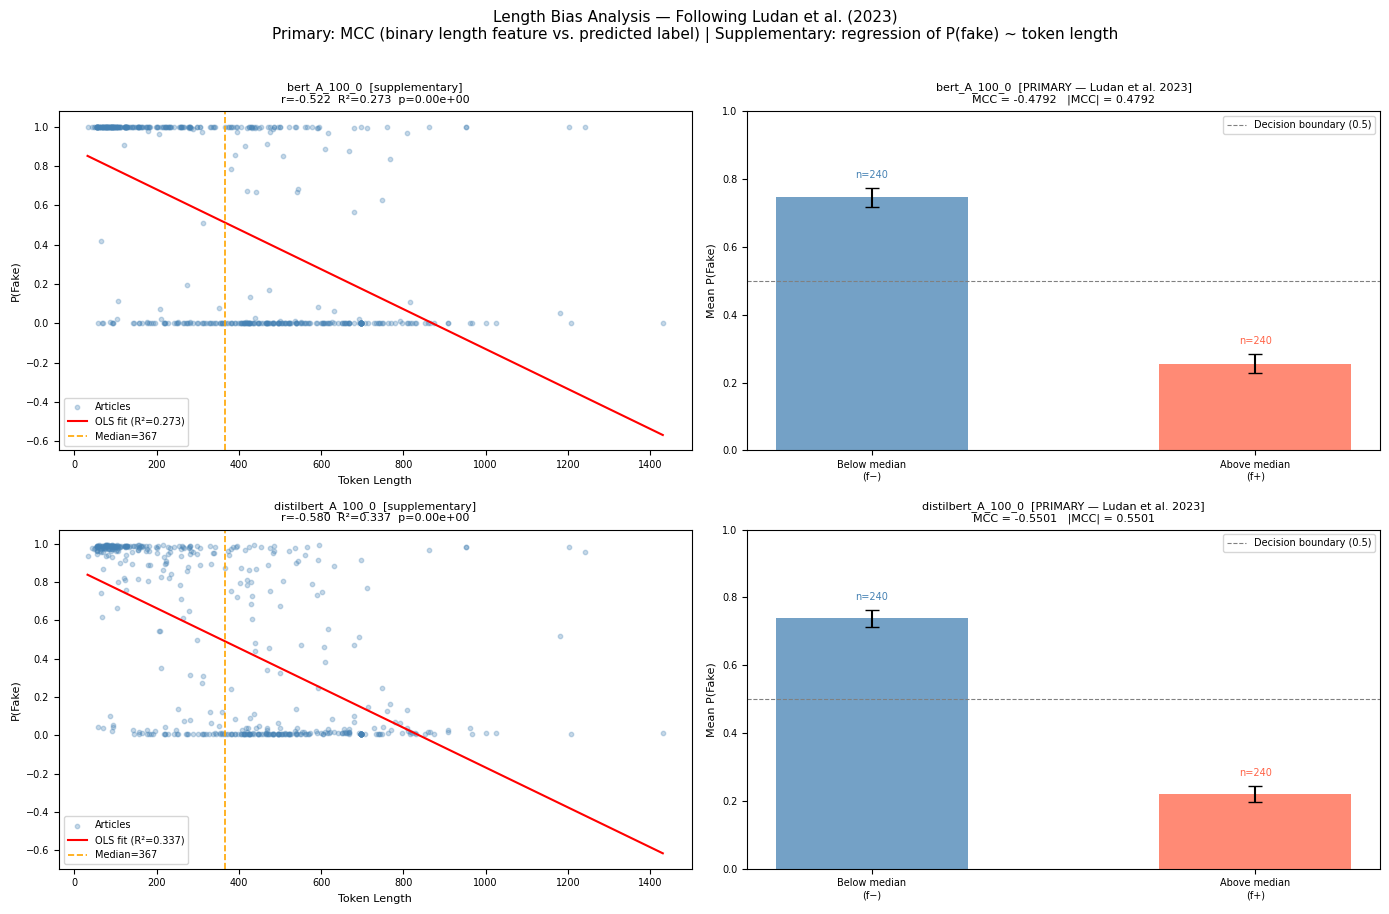

✓ Plot saved → /content/length_bias_mcc.png

HOW TO REPORT THESE RESULTS

Following Ludan et al. (2023), we binarize token length at the median
of the test set and compute the Matthews Correlation Coefficient (MCC)
between each model's predicted label and the binary length feature
(above-median = feature present, f+). An MCC near zero indicates that
the model's decisions are independent of article length.

Suggested text for your paper:
  "To assess whether our models exploit token length as a spurious cue,
  we follow the evaluation protocol of Ludan et al. (2023), binarizing
  token length at the test-set median and computing the Matthews
  Correlation Coefficient (MCC) between each model's predicted label
  and the binary length feature. A low |MCC| indicates that the model
  is not relying on length as a classification shortcut."

Thresholds used:
  |MCC| < 0.10  → negligible length bias
  |MCC| < 0.20  → moderate length signal
  |MCC| ≥ 0.20  → high length bias (model may be using

In [ ]:
# -*- coding: utf-8 -*-
"""
=============================================================================
FILIPINO FAKE NEWS DETECTION — LENGTH BIAS ANALYSIS (MCC METHOD)
Cavite State University · 2026

Methodology follows Ludan et al. (2023) "Explanation-based Finetuning Makes
Models More Robust to Spurious Cues" (ACL 2023):
  - Token length binarized at the median (above = f+, below = f-)
  - Hard predicted labels compared against binary length feature
  - Matthews Correlation Coefficient (MCC) used as the bias metric
  - Linear regression included as a supplementary visual only

Citation:
  Ludan et al. (2023). Explanation-based Finetuning Makes Models More Robust
  to Spurious Cues. ACL 2023, pp. 4420–4441.
=============================================================================
"""

import subprocess, sys

_PACKAGES = [
    "datasets==3.6.0",
    "transformers>=4.38.0",
    "scikit-learn",
    "scipy",
    "matplotlib",
]
for _pkg in _PACKAGES:
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", _pkg],
                   capture_output=True)

# =============================================================================
# IMPORTS
# =============================================================================

import os, gc, json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from scipy import stats
from sklearn.metrics import matthews_corrcoef
import torch
from transformers import AutoTokenizer, AutoModelForSequenceClassification

# =============================================================================
# CONFIGURATION — mirrors Config class from training pipeline
# =============================================================================

SUBCLASSES     = ["HR", "AI-R", "HF", "AI-F"]
SUBCLASS_LABEL = {"HR": 0, "AI-R": 0, "HF": 1, "AI-F": 1}
DATA_SEED      = 42
TEST_SPLIT     = 0.15
VAL_SPLIT      = 0.15

# MCC interpretation thresholds (mirroring paper's R² verdict logic)
MCC_THRESHOLDS = {
    "low":      0.10,   # |MCC| < 0.10 → not relying on length
    "moderate": 0.20,   # 0.10 ≤ |MCC| < 0.20 → some length signal
}

# =============================================================================
# SETUP
# =============================================================================

def mount_drive():
    try:
        from google.colab import drive
        drive.mount("/content/drive")
        print("✓ Google Drive mounted")
        return "/content/drive/MyDrive/filipino_fake_news_hpo"
    except Exception:
        print("⚠  No Drive — using ./output")
        return "./output"

BASE_DIR        = mount_drive()
MODELS_DIR      = os.path.join(BASE_DIR, "models")
DATA_CACHE_PATH = os.path.join(BASE_DIR, "data", "processed_dataset.csv")

def list_trained_models(models_dir):
    found = []
    if not os.path.isdir(models_dir):
        print(f"⚠  Models directory not found: {models_dir}")
        return found
    for mkey in sorted(os.listdir(models_dir)):
        if os.path.isfile(os.path.join(models_dir, mkey, "final", "config.json")):
            found.append(mkey)
    return found

trained_models = list_trained_models(MODELS_DIR)
if not trained_models:
    print("❌  No trained models found.")
else:
    print(f"✓ {len(trained_models)} trained model(s): {', '.join(trained_models)}")

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"✓ Device: {DEVICE}")

# =============================================================================
# DATASET — load from training pipeline cache
# =============================================================================

print("\nLoading dataset from training pipeline cache...")

if not os.path.exists(DATA_CACHE_PATH):
    raise FileNotFoundError(
        f"Cache not found at {DATA_CACHE_PATH}\n"
        "Run the model training pipeline at least once so it creates the cache."
    )

df = pd.read_csv(DATA_CACHE_PATH)
df["label"] = df["label"].astype(int)

if "subclass" not in df.columns:
    print("  ⚠  Cache missing 'subclass' column (old format) — migrating...")
    df["subclass"] = df["label"].map({0: "HR", 1: "HF"})

print(f"✓ Loaded {len(df)} articles  "
      f"(HR={sum(df.subclass=='HR')}, HF={sum(df.subclass=='HF')})")

# =============================================================================
# REPLICATE create_splits() EXACTLY — same seed, same logic as training pipeline
# =============================================================================

def create_splits(df):
    train_parts, val_parts, test_parts = [], [], []
    for sc in SUBCLASSES:
        sc_df = df[df["subclass"] == sc].reset_index(drop=True)
        if len(sc_df) == 0:
            continue
        n       = len(sc_df)
        n_test  = int(n * TEST_SPLIT)
        n_val   = int(n * VAL_SPLIT)
        sc_df = sc_df.sample(frac=1, random_state=DATA_SEED).reset_index(drop=True)
        train_parts.append(sc_df.iloc[:n - n_test - n_val])
        val_parts.append(sc_df.iloc[n - n_test - n_val : n - n_test])
        test_parts.append(sc_df.iloc[n - n_test:])

    test_df = pd.concat(test_parts, ignore_index=True)
    return test_df

test_df     = create_splits(df)
test_texts  = test_df["text"].tolist()
test_labels = test_df["label"].tolist()

print(f"✓ Test set: {len(test_df)} articles  "
      f"({', '.join(f'{sc}={sum(test_df.subclass == sc)}' for sc in SUBCLASSES if sum(test_df.subclass == sc) > 0)})")

# =============================================================================
# CORE ANALYSIS FUNCTION
# Primary metric  : MCC (Ludan et al. 2023, Section 5.3)
# Supplementary   : Linear regression of P(fake) ~ token_length (visual only)
# =============================================================================

def run_length_bias_analysis(mkey, texts, batch_size=16):
    """
    Evaluates whether a trained model relies on token length as a spurious cue.

    Primary metric: Matthews Correlation Coefficient (MCC) between the
    binary length feature (above/below median) and the model's hard predicted
    label. This directly follows Ludan et al. (2023), Section 5.3, where MCC
    is used to measure prediction-feature correlation for binary spurious cues.

    Supplementary: Linear regression of P(fake) ~ raw token length, included
    as a visual diagnostic only and NOT cited as the primary bias measure.
    """
    final_dir = os.path.join(MODELS_DIR, mkey, "final")
    print(f"\n{'─'*64}")
    print(f"  Model : {mkey}")

    tokenizer = AutoTokenizer.from_pretrained(final_dir)
    model     = AutoModelForSequenceClassification.from_pretrained(final_dir)
    model.eval().to(DEVICE)

    token_lengths   = []
    fake_probs      = []
    predicted_labels = []

    for i in range(0, len(texts), batch_size):
        batch = texts[i : i + batch_size]

        # True token count — no truncation (matches paper's character-count intent
        # but at subword token level, consistent with model's actual input space)
        raw_enc = tokenizer(
            batch,
            add_special_tokens=True,
            truncation=False,
            padding=False,
        )
        for ids in raw_enc["input_ids"]:
            token_lengths.append(len(ids))

        # Inference — with truncation (standard 512-token limit)
        inputs = tokenizer(
            batch,
            return_tensors="pt",
            padding=True,
            truncation=True,
            max_length=512,
        )
        inputs = {k: v.to(DEVICE) for k, v in inputs.items()}

        with torch.no_grad():
            logits = model(**inputs).logits

        if logits.shape[-1] == 1:
            p_real  = torch.sigmoid(logits.squeeze(-1)).cpu().numpy()
            p_fake  = 1.0 - p_real
        else:
            probs  = torch.softmax(logits, dim=-1).cpu().numpy()
            p_fake = probs[:, 0]

        fake_probs.extend(p_fake.tolist())
        predicted_labels.extend((p_fake >= 0.5).astype(int).tolist())

        del inputs, logits
        if DEVICE.type == "cuda":
            torch.cuda.empty_cache()

    del model, tokenizer
    gc.collect()
    if DEVICE.type == "cuda":
        torch.cuda.empty_cache()

    token_lengths    = np.array(token_lengths)
    fake_probs       = np.array(fake_probs)
    predicted_labels = np.array(predicted_labels)

    # ------------------------------------------------------------------
    # PRIMARY METRIC: MCC (Ludan et al. 2023, Section 5.3)
    # Binarize length at the median — exactly as the paper defines
    # sentence length as a spurious cue (above-median = feature present)
    # ------------------------------------------------------------------
    median_length  = np.median(token_lengths)
    binary_length  = (token_lengths > median_length).astype(int)  # f+ / f-
    mcc            = matthews_corrcoef(binary_length, predicted_labels)

    # MCC verdict — mirrors paper's framing of low vs. high correlation
    abs_mcc = abs(mcc)
    if abs_mcc < MCC_THRESHOLDS["low"]:
        verdict = "✅ Very low — model is NOT relying on length"
    elif abs_mcc < MCC_THRESHOLDS["moderate"]:
        verdict = "⚠️  Moderate — some length signal present"
    else:
        verdict = "❌ High — model may be using length as a shortcut"

    # ------------------------------------------------------------------
    # SUPPLEMENTARY: Linear regression (visual diagnostic only)
    # NOT cited as the primary bias measure — included for scatter plots
    # ------------------------------------------------------------------
    slope, intercept, r_value, p_value, std_err = stats.linregress(
        token_lengths, fake_probs
    )
    r_squared = r_value ** 2

    # ------------------------------------------------------------------
    # REPORTING
    # ------------------------------------------------------------------
    print(f"  Articles     : {len(token_lengths)}")
    print(f"  Token range  : {token_lengths.min()}–{token_lengths.max()} "
          f"(mean {token_lengths.mean():.1f})")
    print(f"  Median length: {median_length:.0f} tokens  "
          f"(above-median n={binary_length.sum()}, "
          f"below-median n={(1-binary_length).sum()})")
    print()
    print(f"  ── PRIMARY (Ludan et al. 2023) ──────────────────────────")
    print(f"  MCC (length vs. predicted label): {mcc:+.4f}")
    print(f"  |MCC|          : {abs_mcc:.4f}")
    print(f"  Verdict        : {verdict}")
    print()
    print(f"  ── SUPPLEMENTARY (visual only) ──────────────────────────")
    print(f"  Pearson r      : {r_value:+.4f}  (P(fake) ~ token length)")
    print(f"  R²             : {r_squared:.4f}")
    print(f"  p-value        : {p_value:.4e}")
    print(f"  Slope          : {slope:+.6f}  (change in P(fake) per token)")

    return {
        "model"           : mkey,
        "n"               : len(token_lengths),
        "median_length"   : float(median_length),
        "mcc"             : round(float(mcc),       4),
        "abs_mcc"         : round(float(abs_mcc),   4),
        "pearson_r"       : round(float(r_value),   4),
        "r_squared"       : round(float(r_squared), 4),
        "p_value"         : round(float(p_value),   6),
        "slope"           : round(float(slope),     6),
        "intercept"       : round(float(intercept), 4),
        "token_lengths"   : token_lengths,
        "fake_probs"      : fake_probs,
        "binary_length"   : binary_length,
        "predicted_labels": predicted_labels,
    }

# =============================================================================
# RUN ACROSS ALL MODELS
# =============================================================================

all_results = []
for mkey in trained_models:
    result = run_length_bias_analysis(mkey, test_texts)
    all_results.append(result)

# =============================================================================
# SUMMARY TABLE
# =============================================================================

print("\n" + "="*64)
print("SUMMARY — Length Bias Analysis (Ludan et al. 2023 Methodology)")
print("="*64)
print()
print("Primary metric: MCC between binary length feature and predicted label")
print("Interpretation: |MCC| < 0.10 → negligible bias, 0.10–0.20 → moderate,")
print("                |MCC| > 0.20 → high (model relying on length)")
print()

summary_df = pd.DataFrame([
    {
        "Model"    : r["model"],
        "N"        : r["n"],
        "Median L" : int(r["median_length"]),
        "MCC"      : r["mcc"],
        "|MCC|"    : r["abs_mcc"],
        "Pearson r": r["pearson_r"],   # supplementary
        "R²"       : r["r_squared"],   # supplementary
        "p-value"  : r["p_value"],     # supplementary
    }
    for r in all_results
])

print(summary_df.to_string(index=False))
print()
print(f"Mean |MCC| across all models : {summary_df['|MCC|'].mean():.4f}")
print(f"Max  |MCC| across all models : {summary_df['|MCC|'].max():.4f}")

csv_path = "/content/length_bias_mcc.csv"
summary_df.to_csv(csv_path, index=False)
print(f"\n✓ Summary saved → {csv_path}")

# =============================================================================
# PLOTS
# Layout: one row per model
#   Left panel  — scatter of P(fake) vs token length (regression line)
#   Right panel — bar chart: mean P(fake) for below-median vs above-median
#                 (directly illustrates what MCC captures)
# =============================================================================

n_models = len(all_results)
fig = plt.figure(figsize=(14, 4.5 * n_models))
fig.suptitle(
    "Length Bias Analysis — Following Ludan et al. (2023)\n"
    "Primary: MCC (binary length feature vs. predicted label) | "
    "Supplementary: regression of P(fake) ~ token length",
    fontsize=11, y=1.01
)

for i, r in enumerate(all_results):
    # ── LEFT: scatter + regression line ──────────────────────────────
    ax_scatter = fig.add_subplot(n_models, 2, 2 * i + 1)
    ax_scatter.scatter(
        r["token_lengths"], r["fake_probs"],
        alpha=0.3, s=10, color="steelblue", label="Articles"
    )
    x_line = np.linspace(r["token_lengths"].min(), r["token_lengths"].max(), 200)
    y_line = r["slope"] * x_line + r["intercept"]
    ax_scatter.plot(x_line, y_line, color="red", linewidth=1.5,
                    label=f"OLS fit (R²={r['r_squared']:.3f})")
    ax_scatter.axvline(r["median_length"], color="orange", linewidth=1.2,
                       linestyle="--", label=f"Median={r['median_length']:.0f}")
    ax_scatter.set_title(
        f"{r['model']}  [supplementary]\n"
        f"r={r['pearson_r']:+.3f}  R²={r['r_squared']:.3f}  p={r['p_value']:.2e}",
        fontsize=8
    )
    ax_scatter.set_xlabel("Token Length", fontsize=8)
    ax_scatter.set_ylabel("P(Fake)", fontsize=8)
    ax_scatter.tick_params(labelsize=7)
    ax_scatter.legend(fontsize=7)

    # ── RIGHT: mean P(fake) by binary length group (MCC visualised) ──
    ax_bar = fig.add_subplot(n_models, 2, 2 * i + 2)

    below_mask = r["binary_length"] == 0
    above_mask = r["binary_length"] == 1
    groups     = ["Below median\n(f−)", "Above median\n(f+)"]
    means      = [
        r["fake_probs"][below_mask].mean(),
        r["fake_probs"][above_mask].mean(),
    ]
    sems = [
        r["fake_probs"][below_mask].std() / np.sqrt(below_mask.sum()),
        r["fake_probs"][above_mask].std() / np.sqrt(above_mask.sum()),
    ]
    bars = ax_bar.bar(groups, means, yerr=sems, capsize=5,
                      color=["steelblue", "tomato"], alpha=0.75, width=0.5)
    ax_bar.axhline(0.5, color="gray", linewidth=0.8, linestyle="--",
                   label="Decision boundary (0.5)")
    ax_bar.set_ylim(0, 1)
    ax_bar.set_ylabel("Mean P(Fake)", fontsize=8)
    ax_bar.set_title(
        f"{r['model']}  [PRIMARY — Ludan et al. 2023]\n"
        f"MCC = {r['mcc']:+.4f}   |MCC| = {r['abs_mcc']:.4f}",
        fontsize=8
    )
    ax_bar.tick_params(labelsize=7)
    ax_bar.legend(fontsize=7)

    # Annotate bars with group sizes
    n_below = below_mask.sum()
    n_above = above_mask.sum()
    ax_bar.text(0, means[0] + sems[0] + 0.03, f"n={n_below}", ha="center",
                fontsize=7, color="steelblue")
    ax_bar.text(1, means[1] + sems[1] + 0.03, f"n={n_above}", ha="center",
                fontsize=7, color="tomato")

plt.tight_layout()

plot_path = "/content/length_bias_mcc.png"
plt.savefig(plot_path, dpi=150, bbox_inches="tight")
plt.show()
print(f"✓ Plot saved → {plot_path}")

# =============================================================================
# FINAL INTERPRETATION GUIDE
# =============================================================================

print("\n" + "="*64)
print("HOW TO REPORT THESE RESULTS")
print("="*64)
print("""
Following Ludan et al. (2023), we binarize token length at the median
of the test set and compute the Matthews Correlation Coefficient (MCC)
between each model's predicted label and the binary length feature
(above-median = feature present, f+). An MCC near zero indicates that
the model's decisions are independent of article length.

Suggested text for your paper:
  "To assess whether our models exploit token length as a spurious cue,
  we follow the evaluation protocol of Ludan et al. (2023), binarizing
  token length at the test-set median and computing the Matthews
  Correlation Coefficient (MCC) between each model's predicted label
  and the binary length feature. A low |MCC| indicates that the model
  is not relying on length as a classification shortcut."

Thresholds used:
  |MCC| < 0.10  → negligible length bias
  |MCC| < 0.20  → moderate length signal
  |MCC| ≥ 0.20  → high length bias (model may be using length as a cue)
""")